# Combination profile plots — GB 2021 wind damage
Plots using `plot_combination_profile` for the GB 2021 wind damage scenarios.

In [1]:
import sys
import numpy as np
import pandas as pd
import xarray as xr
import pypsa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from functools import reduce

In [2]:
root = Path.cwd()
pypsa_eur_root = root.parent.parent
pypsa_eur_scripts = pypsa_eur_root / "scripts"

sys.path.insert(0, str(pypsa_eur_root))
sys.path.insert(0, str(pypsa_eur_scripts))
sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

In [3]:
from plot_combo import (
    plot_combination_profile, build_storage_dict,
    format_ts_df, format_ts_diff_df, build_eb_diff_by_bus,
)


In [4]:
CONFIG_NAME = "2021-GB"
YEAR        = 2021
CLUSTERS    = 5

WIND_CARRIERS = ["offwind-ac", "offwind-dc", "onwind"]

_results = pypsa_eur_root / "results" / CONFIG_NAME

SCENARIO_VARIANTS = {
    "cap":  f"weather_year_{YEAR}_win_cap_LGLP",
    "dis":  f"weather_year_{YEAR}_win_dis_LGLP",
    "base": f"weather_year_{YEAR}_win_base_LGLP",
}

NETWORK_PATHS = {
    "base":     _results / f"weather_year_{YEAR}_win_dis_LGLP"  / "networks" / "base_s_5_elec_.nc",
    "base_dis": _results / f"weather_year_{YEAR}_win_base_LGLP" / "networks" / "base_s_5_elec__op.nc",
    "cap":      _results / f"weather_year_{YEAR}_win_cap_LGLP"  / "networks" / "base_s_5_elec_.nc",
    "cap_on":   _results / f"weather_year_{YEAR}_win_cap_LGLP"  / "networks" / "base_s_5_elec__op.nc",
    "dis":      _results / f"weather_year_{YEAR}_win_dis_LGLP"  / "networks" / "base_s_5_elec__damaged-dispatch.nc",
}

In [5]:
networks = {label: pypsa.Network(path) for label, path in NETWORK_PATHS.items()}
nc       = pypsa.NetworkCollection(list(networks.values()), index=list(networks.keys()))

_color_overrides = {
    "load_shedding": "darkred",
    "oil":           "dimgray",
    "load":          "#4a4a4a",
}

for n in networks.values():
    if "" in n.carriers.index:
        n.carriers = n.carriers.rename(index={"": "load"})
        for attr in ["generators", "loads", "links", "storage_units", "stores"]:
            df = getattr(n, attr)
            if not df.empty and "carrier" in df.columns:
                df.loc[df["carrier"] == "", "carrier"] = "load"
    for carrier, color in _color_overrides.items():
        if carrier in n.carriers.index:
            n.carriers.loc[carrier, "color"] = color
    remaining = n.carriers[n.carriers.color.isna() | n.carriers.color.eq("")].index
    n.carriers.loc[remaining, "color"] = "lightgrey"

color_map = networks["base_dis"].carriers.color.to_dict()

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current:

In [6]:
SUP_CARRIERS    = ['biomass', 'offwind-ac', 'offwind-dc', 'onwind', 'nuclear'
                   'solar', 'solar-hsat', 'load_shedding', 'ror', 'hydro']
CHARGE_CARRIERS = ['H2 electrolysis', 'H2 fuel cell', 'battery', 'PHS']
STOR_CARRIERS   = ['H2 fuel cell']
solar_group = ['solar', 'solar-hsat']
offwind_group = ['offwind-ac', 'offwind-dc']

In [7]:
# Damage profile paths — one nc file per wind carrier, per scenario
_base_dir = pypsa_eur_root / "resources" / CONFIG_NAME

pel_nc_paths_dis = {
    c: _base_dir / SCENARIO_VARIANTS["dis"] / "damage_profiles" / f"{c}_damage_{CLUSTERS}.nc"
    for c in WIND_CARRIERS
}

pel_nc_paths_cap = {
    c: _base_dir / SCENARIO_VARIANTS["cap"] / "damage_profiles" / f"{c}_damage_{CLUSTERS}.nc"
    for c in WIND_CARRIERS
}

# cap_on shares the same damage profiles as cap
pel_nc_paths_cap_on = pel_nc_paths_cap

In [8]:
def _load_damage_aligned(damage_nc_path, base_network, carrier, date_range=None):
    """Load damage profile and align with network generators (bus-level)."""
    damage_df = xr.open_dataset(damage_nc_path)["profile"].to_pandas()
    damage_df.index = pd.to_datetime(damage_df.index)
    if date_range is not None:
        damage_df = damage_df.loc[date_range[0]:date_range[1]]

    gens = base_network.generators[
        (base_network.generators.carrier == carrier) &
        (base_network.generators.p_nom_opt > 0)
    ]
    capacities = pd.Series(gens["p_nom_opt"].values, index=gens["bus"].values)

    common_buses = damage_df.columns.intersection(capacities.index)
    damage_df  = damage_df[common_buses]
    capacities = capacities[common_buses]

    p_max_pu_dict = {}
    for gen_idx, gen in gens[gens["bus"].isin(common_buses)].iterrows():
        if gen_idx in base_network.generators_t.p_max_pu.columns:
            ts = base_network.generators_t.p_max_pu[gen_idx]
        else:
            ts = pd.Series(gen["p_max_pu"], index=damage_df.index)
        ts.index = pd.to_datetime(ts.index)
        p_max_pu_dict[gen["bus"]] = ts.reindex(damage_df.index)

    return damage_df, pd.DataFrame(p_max_pu_dict), capacities


def _aggregate(df, freq):
    if freq == "h":     return df
    if freq == "total": return pd.DataFrame([df.sum()], index=pd.Index([df.index[0]]))
    return df.resample(freq).sum()


def compute_potential_energy_loss(damage_nc_path, base_network, carrier,
                                   date_range=None, freq="MS", by_bus=False):
    """
    Potential energy loss (MWh) for wind.

    PEL = damage_fraction x p_max_pu x p_nom_opt, summed per period.

    by_bus : True -> one column per bus; False -> fleet total.
    """
    damage_df, p_max_pu_df, capacities = _load_damage_aligned(
        damage_nc_path, base_network, carrier, date_range
    )
    pel_df = _aggregate(damage_df * p_max_pu_df * capacities, freq)
    if by_bus:
        return pel_df
    return pel_df.sum(axis=1).rename("fleet").to_frame()

In [9]:
def _pivot(ts_eb, network, carrier, bus_carrier):
    mask = (
        (ts_eb["network"]     == network) &
        (ts_eb["carrier"]     == carrier) &
        (ts_eb["bus_carrier"] == bus_carrier)
    )
    return (
        ts_eb[mask]
        .pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum")
        .fillna(0)
    )

def get_soc_by_bus(n, carrier):
    store_idx = n.stores.index[n.stores.carrier == carrier]
    if not store_idx.empty:
        df = n.stores_t.e[store_idx].copy()
        df.columns = n.stores.loc[store_idx, "bus"]
        return df.T.groupby(level=0).sum().T
    su_idx = n.storage_units.index[n.storage_units.carrier == carrier]
    if not su_idx.empty:
        df = n.storage_units_t.state_of_charge[su_idx].copy()
        df.columns = n.storage_units.loc[su_idx, "bus"]
        return df.T.groupby(level=0).sum().T
    raise ValueError(f"No Store or StorageUnit found for carrier '{carrier}'")

def _fleet_price(n):
    ac     = n.buses.index[n.buses.carrier == "AC"]
    prices = n.buses_t.marginal_price[ac]
    load_w = n.loads_t.p_set.reindex(columns=ac).fillna(0)
    return (prices * load_w).sum(axis=1) / load_w.sum(axis=1).replace(0, np.nan)

In [10]:
def prepare_combo_data(base, scen, *, nc, pel_nc_paths=None):
    n_base = nc.networks[base]
    n_scen = nc.networks[scen]

    EXCLUDE = ["coal", "ocgt", "ccgt"]
    ts_eb   = format_ts_df(nc, stat="energy_balance")
    ts_eb   = ts_eb[~ts_eb["carrier"].isin(EXCLUDE)]
    ts_diff = format_ts_diff_df(nc.networks, stat="energy_balance", base=base)

    def p(network, carrier, bus_carrier):
        return _pivot(ts_eb, network, carrier, bus_carrier)

    ls_df      = p(scen, "load_shedding", "AC")
    ls_df[ls_df < 0.001] = 0

    fc_df      = p(scen, "H2 fuel cell", "AC")
    fc_diff_df = fc_df - p(base, "H2 fuel cell", "AC")

    elec_scen_df = p(scen, "H2 electrolysis", "H2")
    elec_diff_df = elec_scen_df - p(base, "H2 electrolysis", "H2")

    line_df      = p(scen, "AC", "AC")
    line_base_df = p(base, "AC", "AC")
    line_diff_df = line_df - line_base_df

    dc_df      = p(scen, "DC", "AC")
    dc_base_df = p(base, "DC", "AC")
    dc_diff_df = dc_df - dc_base_df

    flow_df      = line_df.add(dc_df, fill_value=0)
    flow_base_df = line_base_df.add(dc_base_df, fill_value=0)
    flow_diff_df = flow_df - flow_base_df

    soc_scen        = get_soc_by_bus(n_scen, "H2")
    soc_base        = get_soc_by_bus(n_base, "H2")
    soc_diff_df     = soc_scen - soc_base
    h2_e_nom_by_bus = (
        n_scen.stores[n_scen.stores.carrier == "H2"]
        .groupby("bus")["e_nom_opt"].sum()
    )

    price_scen  = _fleet_price(n_scen)
    price_base_ = _fleet_price(n_base)
    price_fleet = price_scen.to_frame("fleet")
    price_diff  = (price_scen - price_base_).to_frame("fleet")

    if pel_nc_paths is not None:
        pel_dict_win = {
            carrier: compute_potential_energy_loss(
                path, n_base, carrier, freq="h", by_bus=True
            )
            for carrier, path in pel_nc_paths.items()
        }
    else:
        pel_dict_win = {}

    storage_dict = build_storage_dict(nc, scen)

    return {
        "ts_diff":         ts_diff,
        "ls_df":           ls_df,
        "fc_df":           fc_df,
        "fc_diff_df":      fc_diff_df,
        "elec_scen_df":    elec_scen_df,
        "elec_diff_df":    elec_diff_df,
        "line_df":         line_df,
        "line_base_df":    line_base_df,
        "line_diff_df":    line_diff_df,
        "dc_df":           dc_df,
        "dc_base_df":      dc_base_df,
        "dc_diff_df":      dc_diff_df,
        "flow_df":         flow_df,
        "flow_base_df":    flow_base_df,
        "flow_diff_df":    flow_diff_df,
        "soc_scen":        soc_scen,
        "soc_base":        soc_base,
        "soc_diff_df":     soc_diff_df,
        "h2_e_nom_by_bus": h2_e_nom_by_bus,
        "price_fleet":     price_fleet,
        "price_diff":      price_diff,
        "pel_dict_win":    pel_dict_win,
        "storage_dict":    storage_dict,
    }

## Plots

## Base

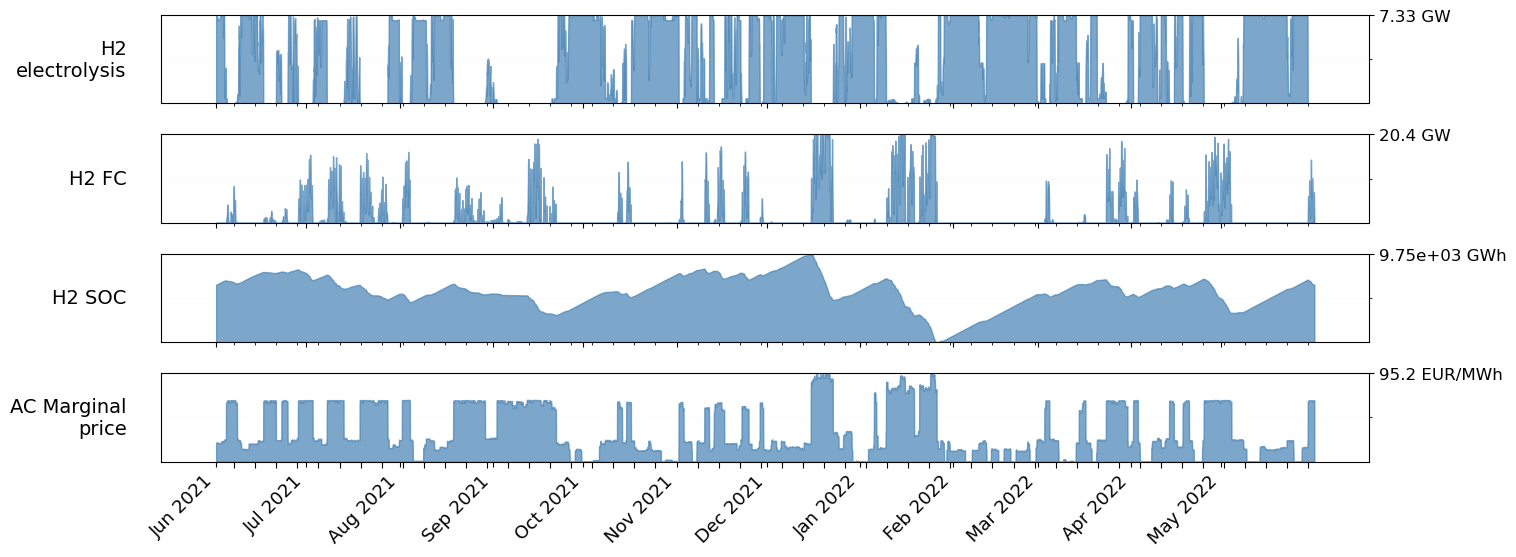

In [12]:
# Base network — H2 electrolysis, SOC, price (no diff)
base = "base_dis"
scen = "base_dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=None)

fig, axes = plot_combination_profile(
    carrier_groups={
        "offwind-ac": "offwind-ac",
        "offwind-dc": "offwind-dc",
        "onwind":     "onwind",
    },
    components={
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "AC Marginal\nprice": {
            "type": "direct", "data": d["price_fleet"],
            "render": "area", "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-06-01", f"{YEAR+1}-05-31"),
    show_day_ticks=False,
    title=None,
    fontsize=14,
    label_gap=25,
)

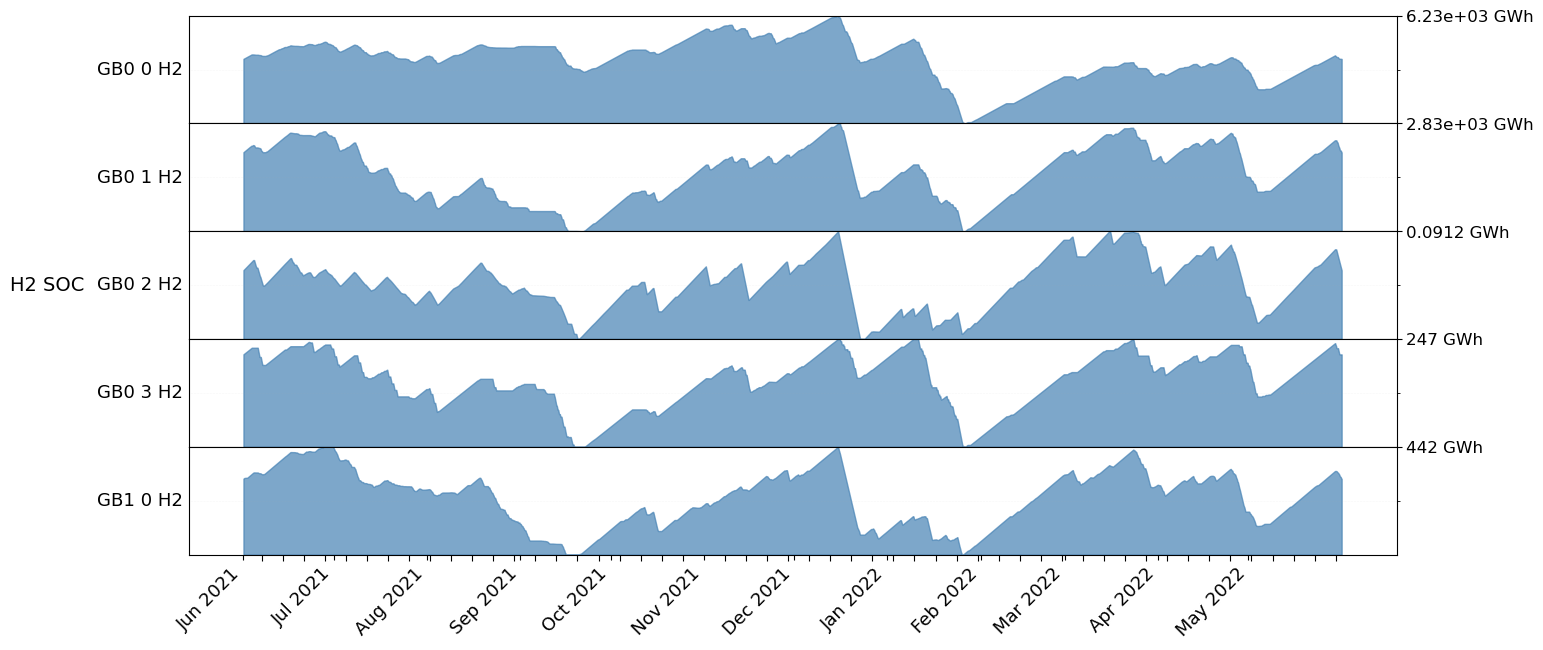

In [87]:
# Base network — H2 electrolysis, SOC, price (no diff)
base = "base_dis"
scen = "base_dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=None)

fig, axes = plot_combination_profile(
    carrier_groups={
        "offwind-ac": "offwind-ac",
        "offwind-dc": "offwind-dc",
        "onwind":     "onwind",
    },
    components={
        # "H2\nelectrolysis": {
        #     "type": "direct", "data": d["elec_scen_df"],
        #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        # "H2 FC": {
        #     "type": "direct", "data": d["fc_df"],
        #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        # "AC Marginal\nprice": {
        #     "type": "direct", "data": d["price_fleet"],
        #     "render": "area", "unit": "EUR/MWh", "row_height": 1.2,
        # },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-06-01", f"{YEAR+1}-05-31"),
    show_day_ticks=False,
    title=None,
    fontsize=14,
    label_gap=75,
)

## Damaged dispatch

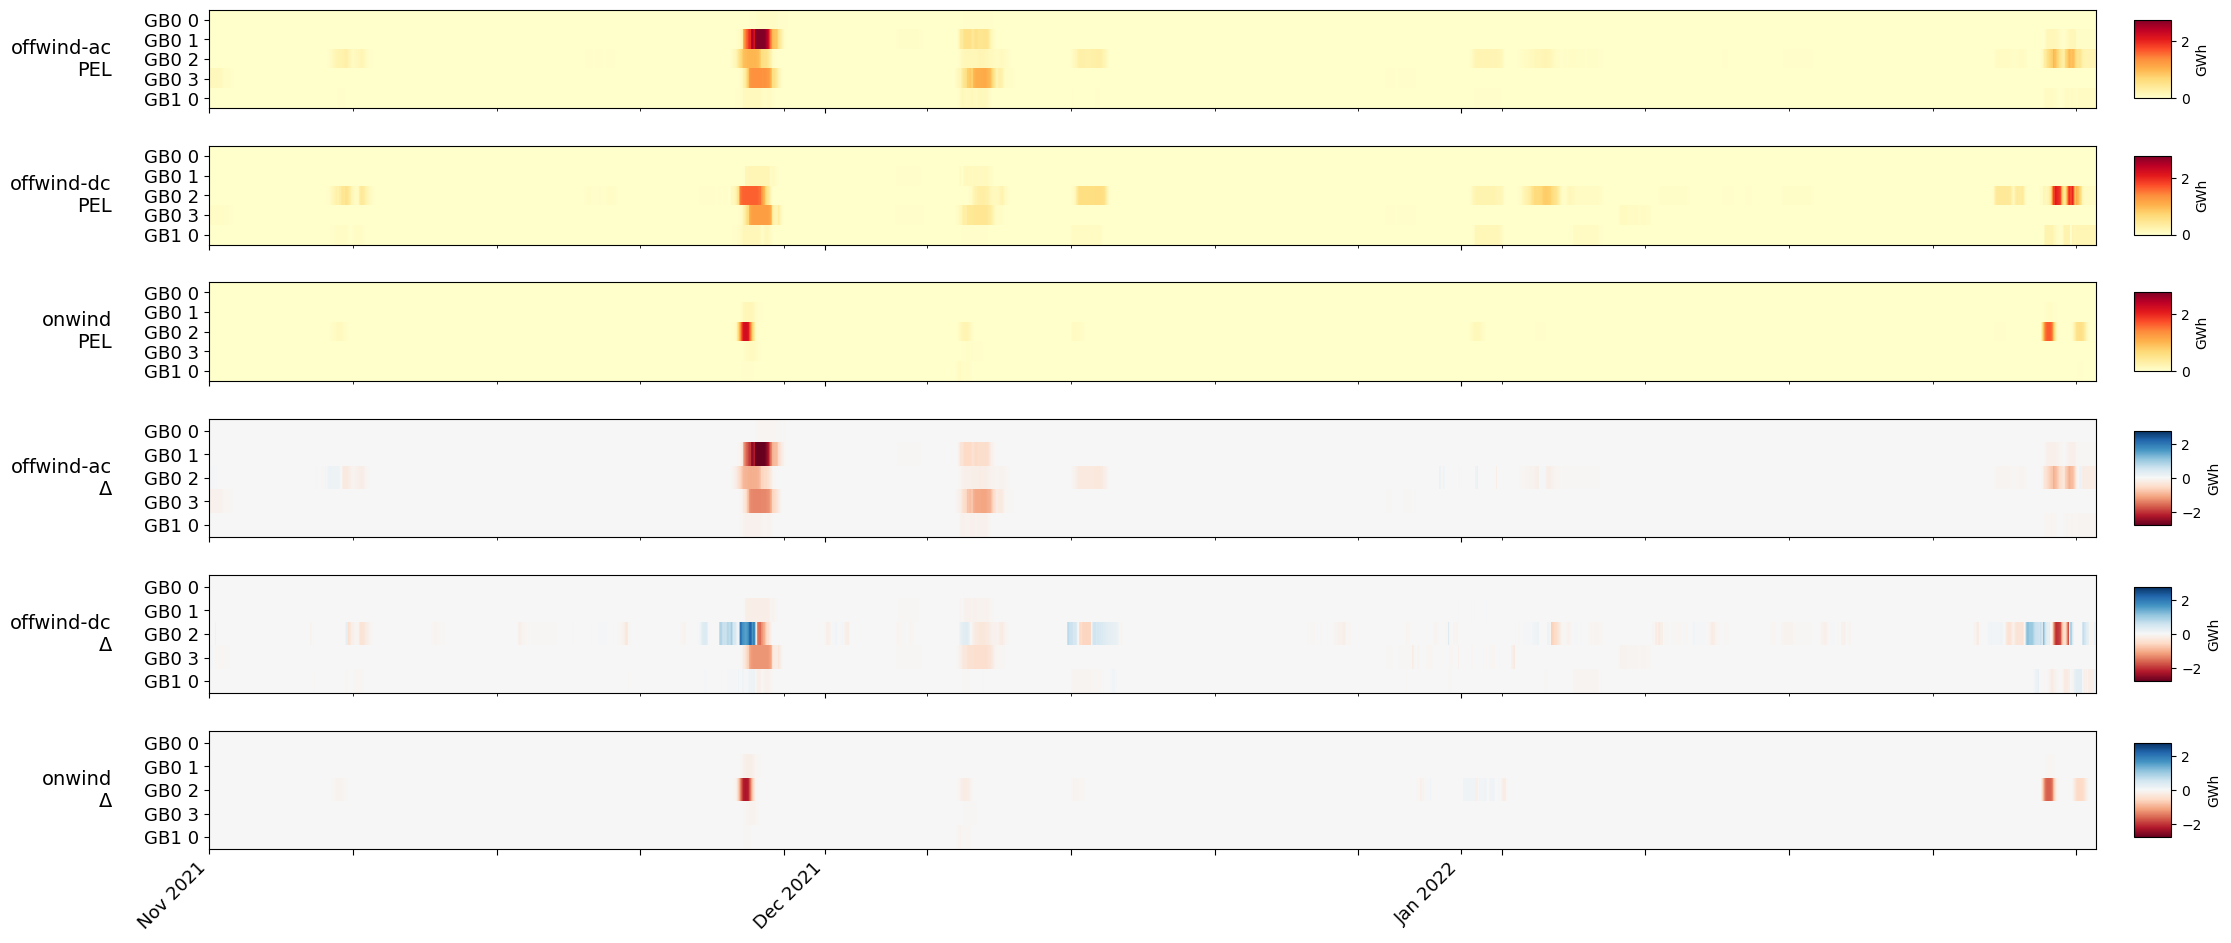

In [81]:
# Wind PEL vs EB diff — per bus
base = "base_dis"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_dis)

fig, axes = plot_combination_profile(
    carrier_groups={c: c for c in WIND_CARRIERS},
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_win"],
            "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
        },
        "\u0394": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "wind", "row_height": 1.8,
        },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-11-01", f"{YEAR+1}-01-31"),
    title=None,
    fontsize=14,
    label_gap=70,
    fig_width=25,
)

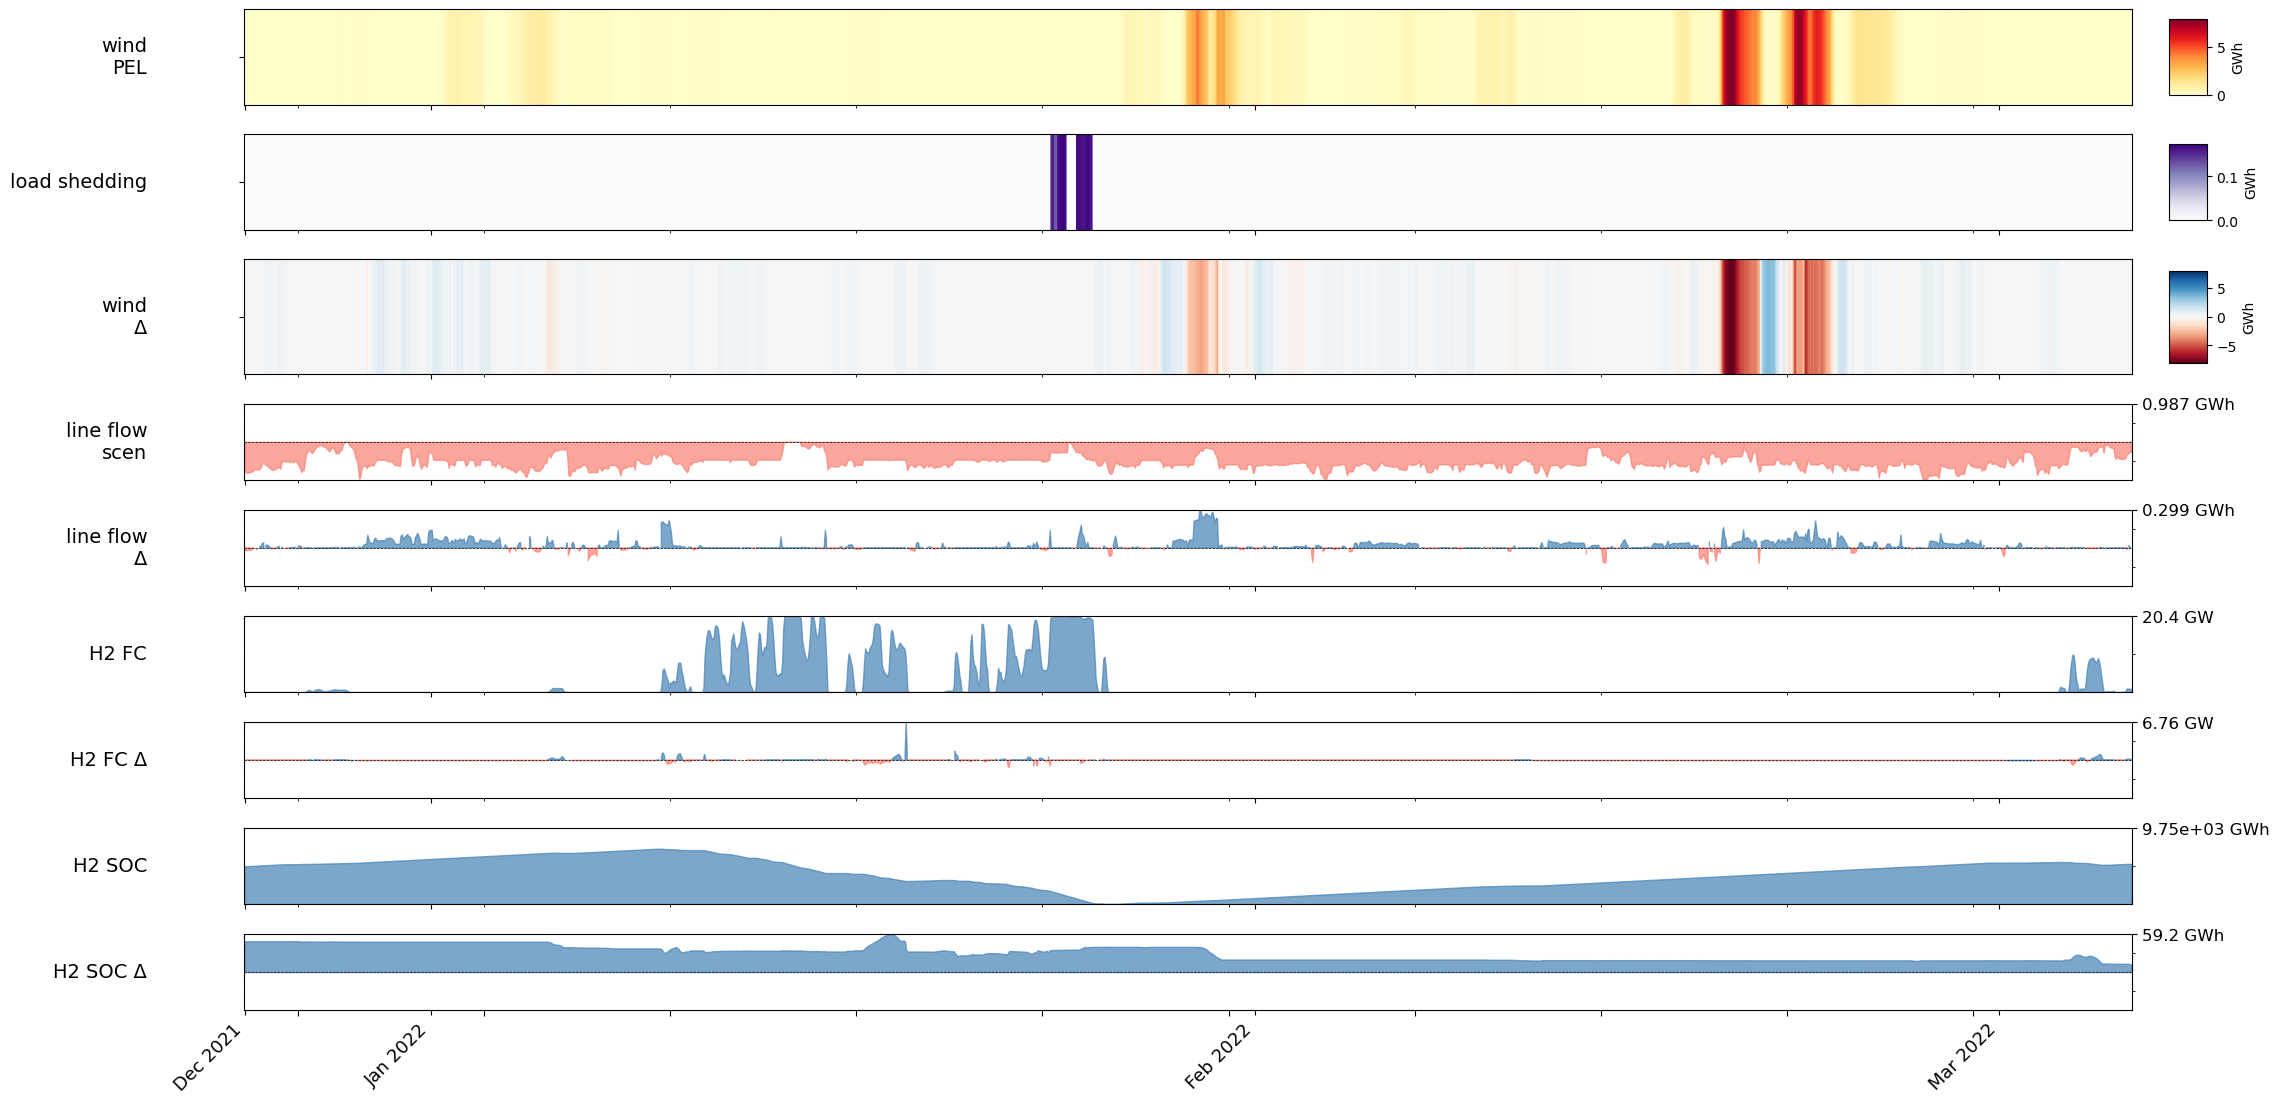

In [13]:
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_dis)

diff_carrier_groups = {
    "wind": ["onwind"] + offwind_group
}

fig, axes = plot_combination_profile(
    carrier_groups=diff_carrier_groups,
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_win"],
            "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
        },
        "load shedding": {
            "type": "direct", "data": d["ls_df"],
            "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        },
        "\u0394": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "wind", "row_height": 1.8,
        },
        "line flow\nscen": {
            "type": "direct", "data": d["line_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "line flow\n\u0394": {
            "type": "direct", "data": d["line_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC \u0394": {
            "type": "direct", "data": d["fc_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-12-25", f"{YEAR+1}-03-05"),
    title=None,
    fontsize=14,
    label_gap=70,
    fig_width=25,
)


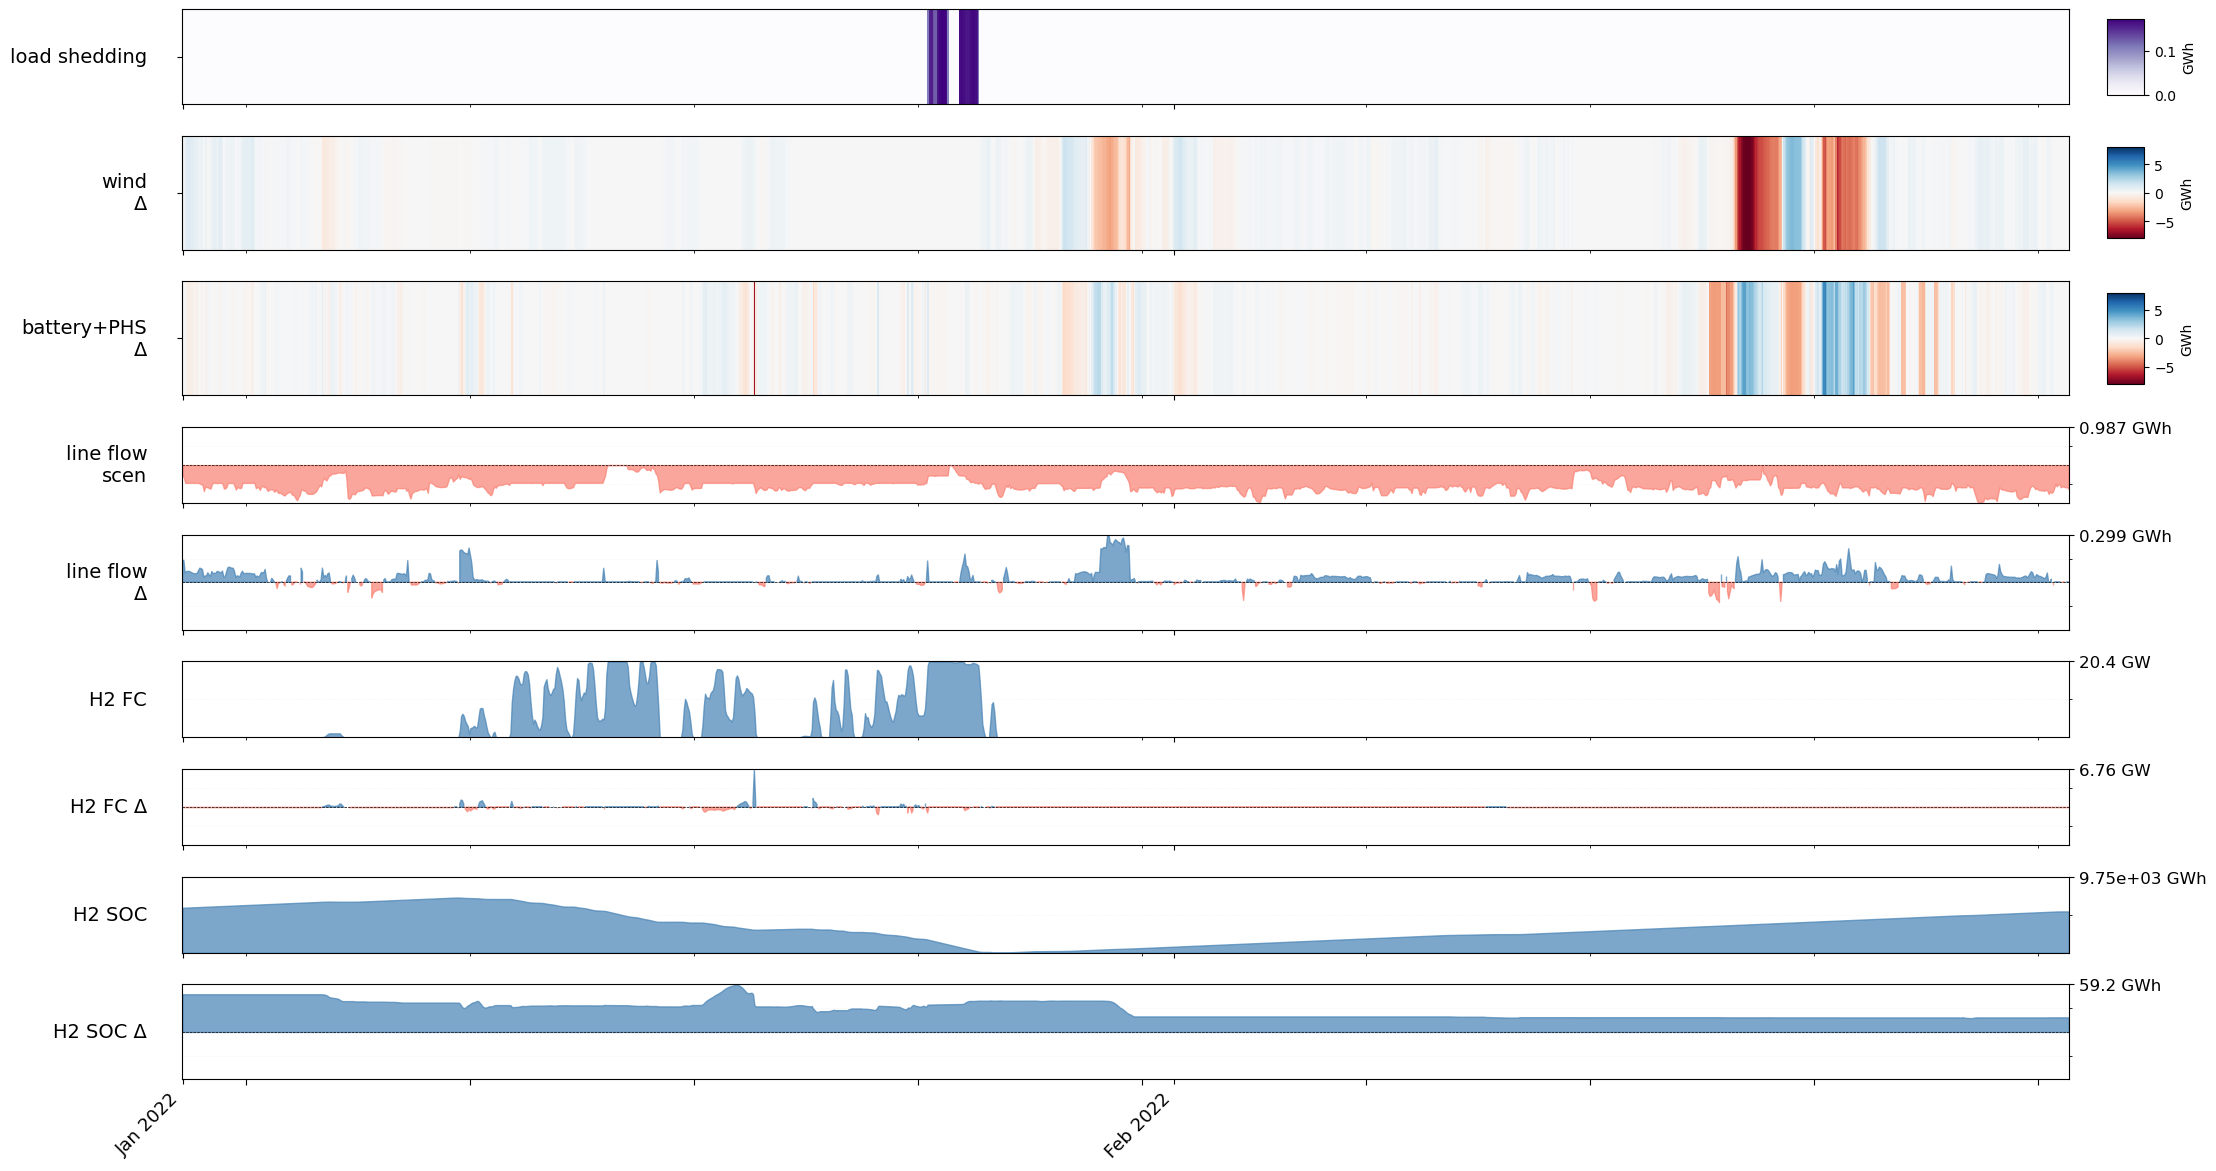

In [37]:
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_dis)

diff_carrier_groups = {
    "wind": ["onwind"] + offwind_group,
    "battery+PHS": ["battery", "PHS"],
}

fig, axes = plot_combination_profile(
    carrier_groups=diff_carrier_groups,
    components={
        # "PEL": {
        #     "type": "carrier_dict", "data": d["pel_dict_win"],
        #     "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
        # },
        "load shedding": {
            "type": "direct", "data": d["ls_df"],
            "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        },
        "\u0394": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "wind", "row_height": 1.8,
        },
        "line flow\nscen": {
            "type": "direct", "data": d["flow_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "line flow\n\u0394": {
            "type": "direct", "data": d["flow_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.5,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC \u0394": {
            "type": "direct", "data": d["fc_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.5,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR+1}-01-01", f"{YEAR+1}-02-28"),
    title=None,
    fontsize=14,
    label_gap=25,
    fig_width=25,
)


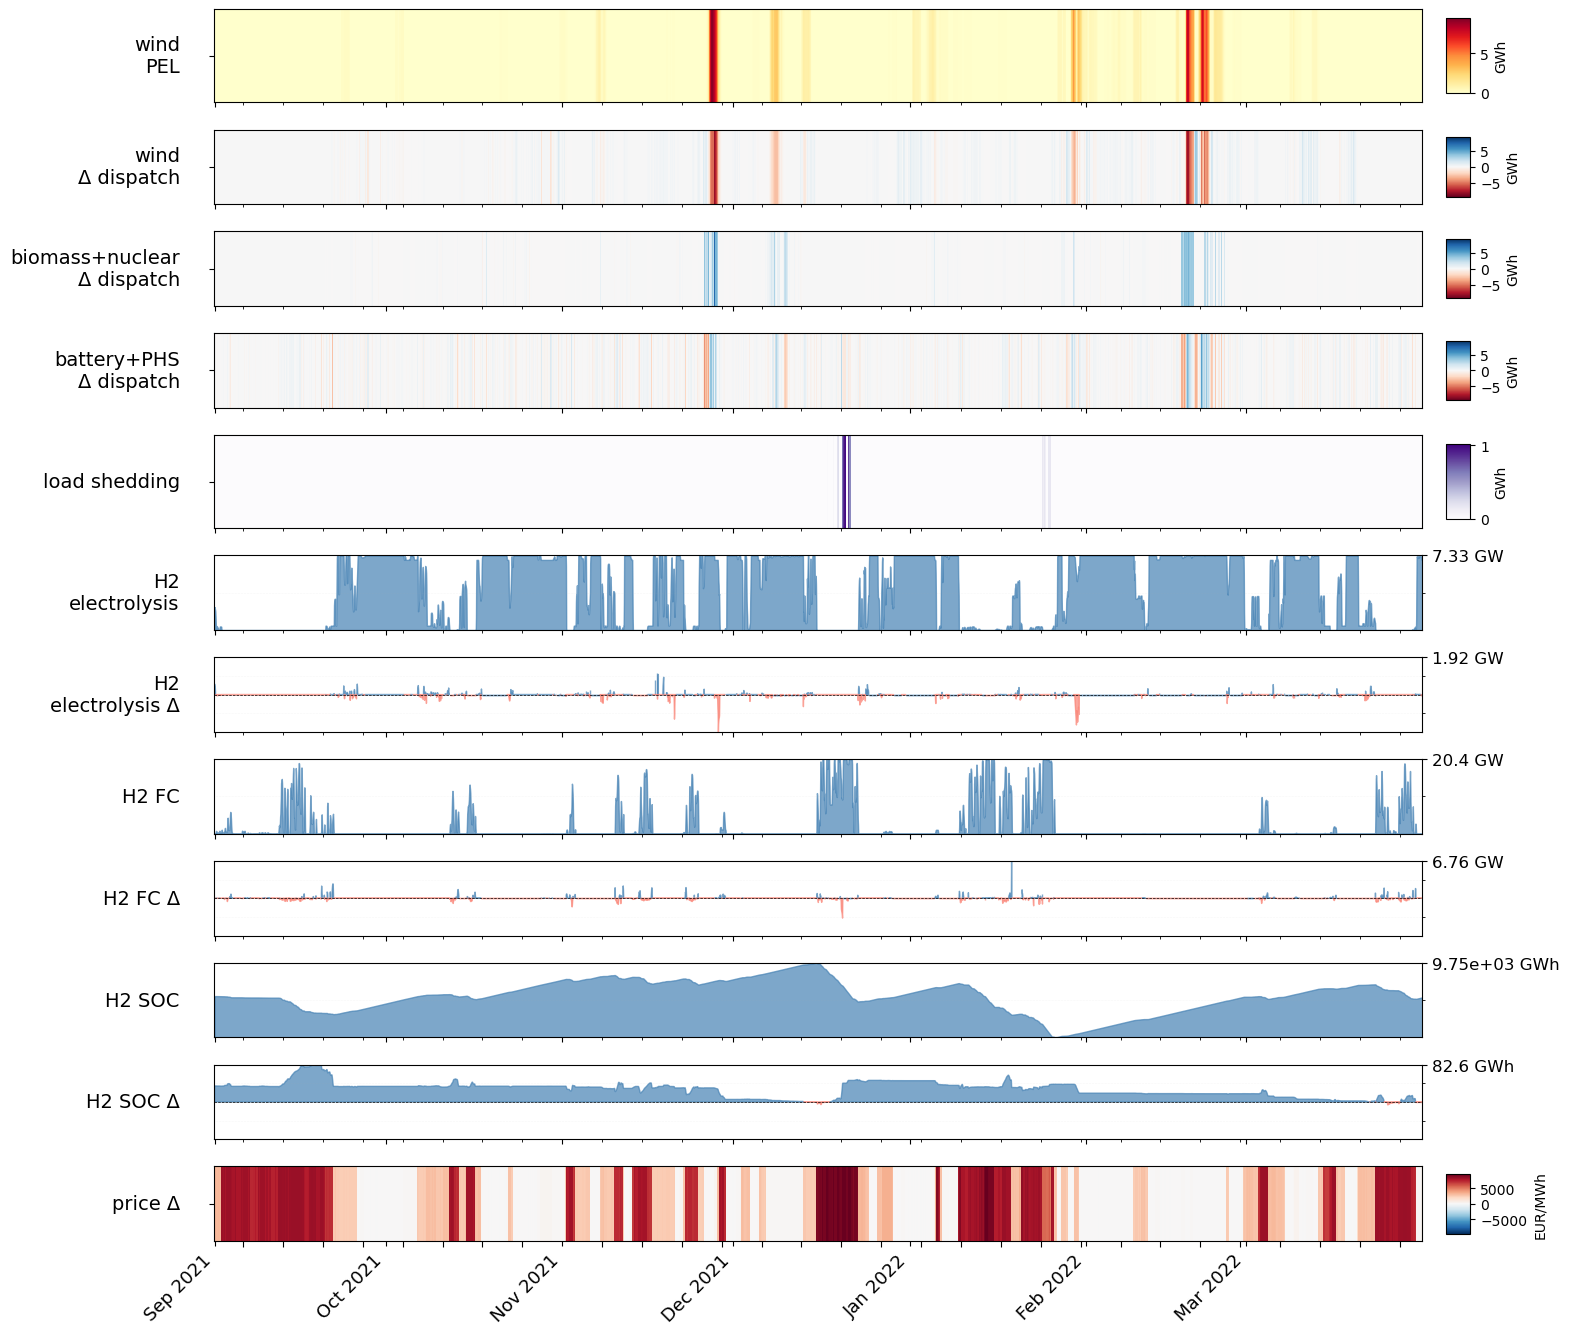

In [34]:
# Damaged dispatch — H2, SOC, price with diffs, winter
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_dis)

ls_diff = build_eb_diff_by_bus(d["ts_diff"], "load_shedding", scen) * 1e-3
bat_phs_diff = (
    build_eb_diff_by_bus(d["ts_diff"], "battery", scen)
    + build_eb_diff_by_bus(d["ts_diff"], "PHS", scen)
) * 1e-3

fig, axes = plot_combination_profile(
    carrier_groups={
        "wind":            ["onwind"] + offwind_group,
        "biomass+nuclear": ["biomass", "nuclear"],
        "battery+PHS": ["battery", "PHS"],
    },
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_win"],
            "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
        },
        "\u0394 dispatch": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "wind", "row_height": 1.2,
        },
        # "battery+PHS \u0394": {
        #     "type": "direct", "data": bat_phs_diff,
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "unit": "GWh", "row_height": 1.2,
        # },
        "load shedding": {
            "type": "direct", "data": d["ls_df"],
            "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        },
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2\nelectrolysis \u0394": {
            "type": "direct", "data": d["elec_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC \u0394": {
            "type": "direct", "data": d["fc_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "price \u0394": {
            "type": "direct", "data": d["price_diff"],
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-09-01", f"{YEAR+1}-03-31"),
    title=None,
    fontsize=14,
    label_gap=25,
)



In [24]:
SUP_CARRIERS

['biomass',
 'offwind-ac',
 'offwind-dc',
 'onwind',
 'nuclearsolar',
 'solar-hsat',
 'load_shedding',
 'ror',
 'hydro']

In [30]:
SUP_CARRIERS_no_ls = [
    'biomass',
 'offwind-ac',
 'offwind-dc',
 'onwind',
 'nuclear',
 'solar',
 'solar-hsat',
 'ror',
 'hydro']

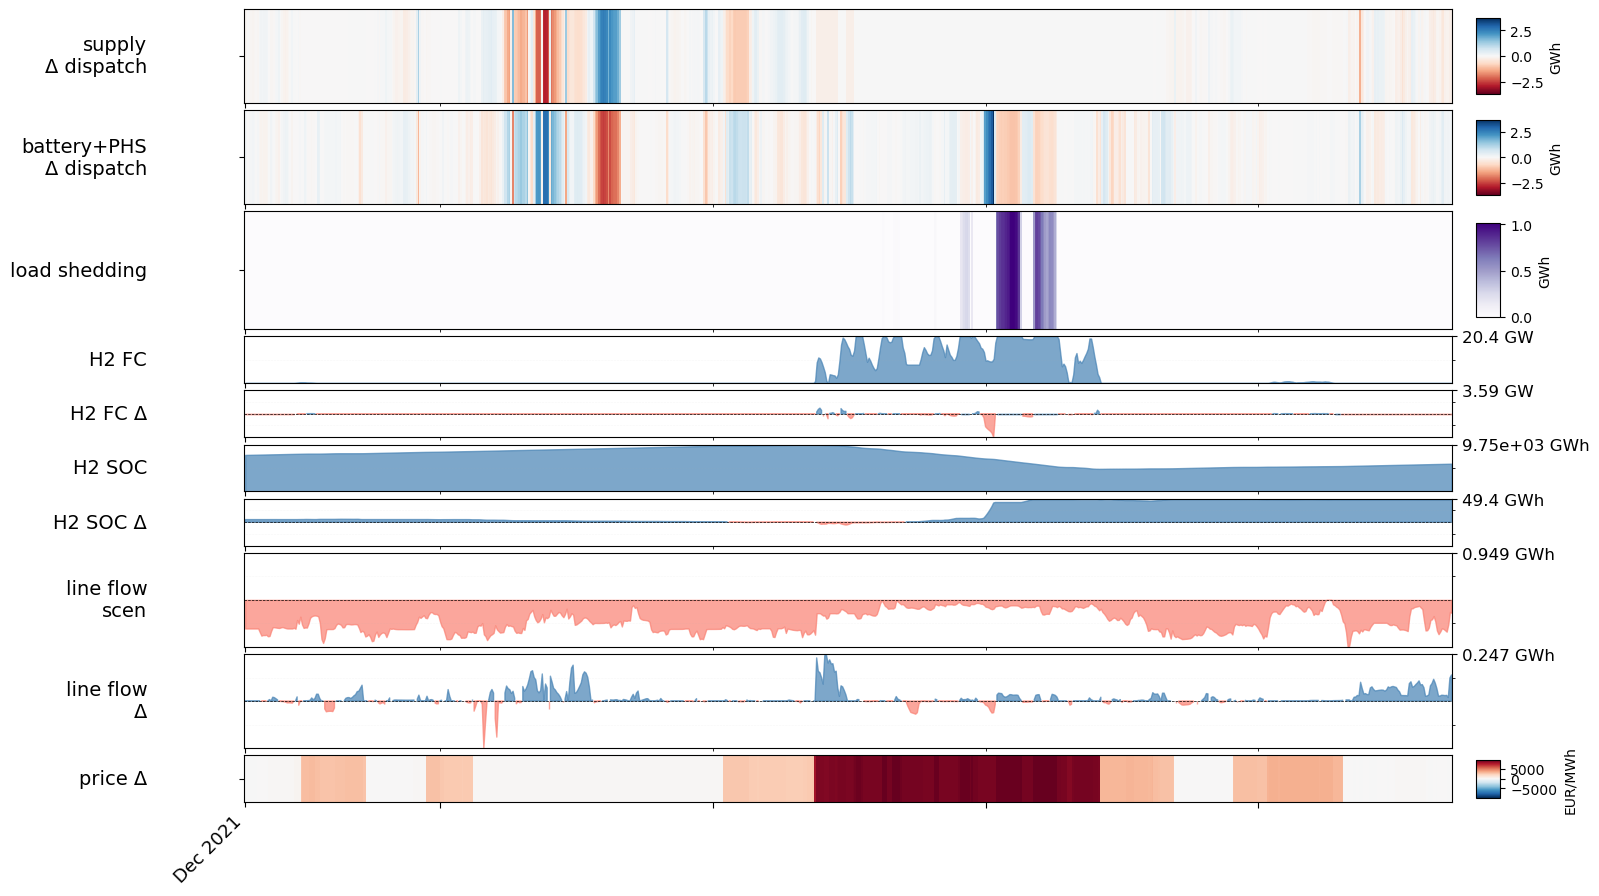

In [47]:
# Damaged dispatch — H2, SOC, price with diffs, winter
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_dis)

ls_diff = build_eb_diff_by_bus(d["ts_diff"], "load_shedding", scen) * 1e-3

fig, axes = plot_combination_profile(
    carrier_groups={
        # "offwind-ac":  "offwind-ac",
        # "offwind-dc":  "offwind-dc",
        # "onwind":      "onwind",
        # "wind": ["onwind"] + offwind_group,
        # "ror":      "ror",
        # "hydro":    "hydro",
        # "biomass+nuclear": ["biomass","nuclear"],
        "supply": SUP_CARRIERS_no_ls,
        "battery+PHS": ["battery", "PHS"],
    },
    components={
        # "PEL": {
        #     "type": "carrier_dict", "data": d["pel_dict_win"],
        #     "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
        # },
        "\u0394 dispatch": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "wind", "row_height": 1.2,
        },
        "load shedding": {
            "type": "direct", "data": d["ls_df"],
            "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        },

        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 0.6,
        },
        "H2 FC \u0394": {
            "type": "direct", "data": d["fc_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 0.6,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 0.6,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 0.6,
        },
        # "H2\nelectrolysis": {
        #     "type": "direct", "data": d["elec_scen_df"],
        #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        # "H2\nelectrolysis \u0394": {
        #     "type": "direct", "data": d["elec_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        "line flow\nscen": {
            "type": "direct", "data": d["flow_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "line flow\n\u0394": {
            "type": "direct", "data": d["flow_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "price \u0394": {
            "type": "direct", "data": d["price_diff"],
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 0.6,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-12-01", f"{YEAR}-12-31"),
    title=None,
    fontsize=14,
    label_gap=70,
    component_gap=0.1
)


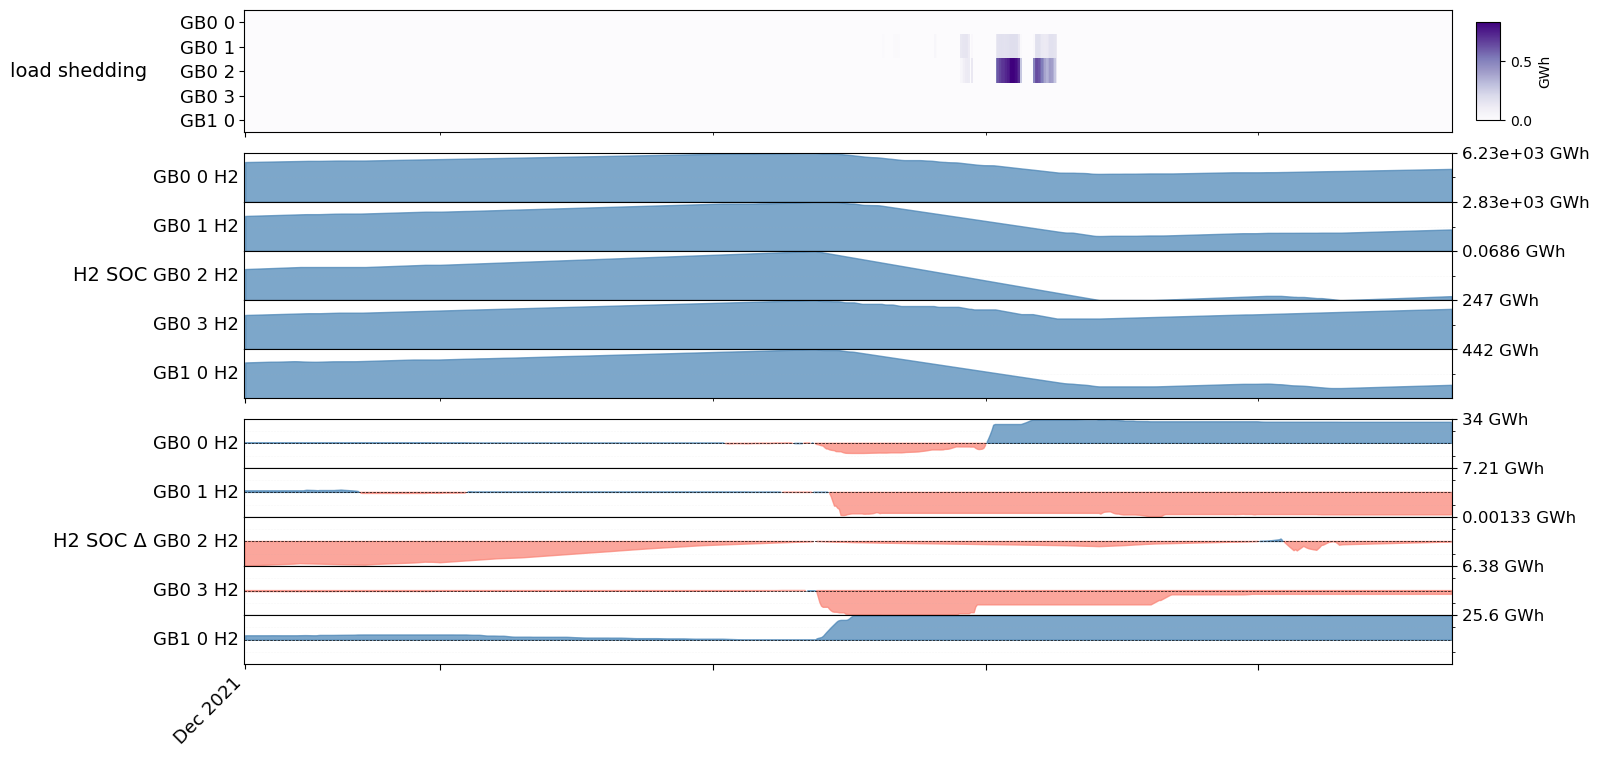

In [48]:
# Damaged dispatch — H2, SOC, price with diffs, winter
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_dis)

ls_diff = build_eb_diff_by_bus(d["ts_diff"], "load_shedding", scen) * 1e-3

fig, axes = plot_combination_profile(
    carrier_groups={
        # "offwind-ac":  "offwind-ac",
        # "offwind-dc":  "offwind-dc",
        # "onwind":      "onwind",
        # "wind": ["onwind"] + offwind_group,
        # "ror":      "ror",
        # "hydro":    "hydro",
        # "biomass+nuclear": ["biomass","nuclear"],
        "supply": SUP_CARRIERS_no_ls,
        "battery+PHS": ["battery", "PHS"],
    },
    components={
        # "PEL": {
        #     "type": "carrier_dict", "data": d["pel_dict_win"],
        #     "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
        # },
        # "\u0394 dispatch": {
        #     "type": "ts_diff", "data": d["ts_diff"], "network": scen,
        #     "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
        #     "vmax_group": "wind", "row_height": 1.2,
        # },
        "load shedding": {
            "type": "direct", "data": d["ls_df"],
            "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        },

        # "H2 FC": {
        #     "type": "direct", "data": d["fc_df"],
        #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 0.6,
        # },
        # "H2 FC \u0394": {
        #     "type": "direct", "data": d["fc_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "multiplier": 1e-3, "unit": "GW", "row_height": 0.6,
        # },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 0.6,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 0.6,
            # "vmax_group": "store_change"
        },
        # "H2\nelectrolysis": {
        #     "type": "direct", "data": d["elec_scen_df"],
        #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        # "H2\nelectrolysis \u0394": {
        #     "type": "direct", "data": d["elec_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        # "line flow\nscen": {
        #     "type": "direct", "data": d["flow_df"],
        #     "render": "area", "symmetric": True,
        #     "multiplier": 1e-3, "unit": "GWh",
        #     "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        # },
        # "line flow\n\u0394": {
        #     "type": "direct", "data": d["flow_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "multiplier": 1e-3, "unit": "GWh",
        #     "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        # },
        # "price \u0394": {
        #     "type": "direct", "data": d["price_diff"],
        #     "render": "heatmap", "cmap": "RdBu_r",
        #     "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        # },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-12-01", f"{YEAR}-12-31"),
    title=None,
    fontsize=14,
    label_gap=70,
    component_gap=0.1
)


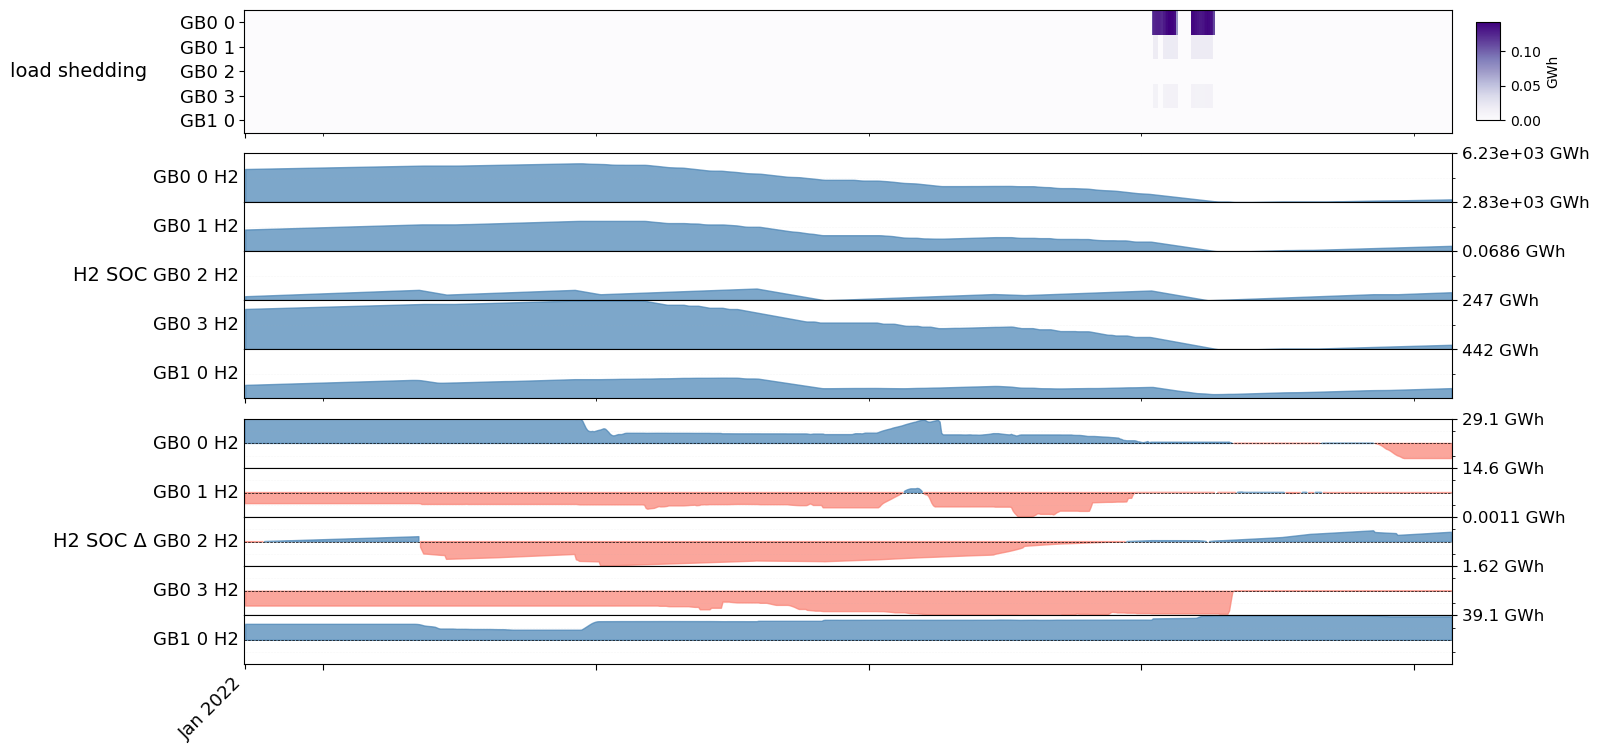

In [46]:
# Damaged dispatch — H2, SOC, price with diffs, winter
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_dis)

ls_diff = build_eb_diff_by_bus(d["ts_diff"], "load_shedding", scen) * 1e-3

fig, axes = plot_combination_profile(
    carrier_groups={
        # "offwind-ac":  "offwind-ac",
        # "offwind-dc":  "offwind-dc",
        # "onwind":      "onwind",
        # "wind": ["onwind"] + offwind_group,
        # "ror":      "ror",
        # "hydro":    "hydro",
        # "biomass+nuclear": ["biomass","nuclear"],
        "supply": SUP_CARRIERS_no_ls,
        "battery+PHS": ["battery", "PHS"],
    },
    components={
        # "PEL": {
        #     "type": "carrier_dict", "data": d["pel_dict_win"],
        #     "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
        # },
        # "\u0394 dispatch": {
        #     "type": "ts_diff", "data": d["ts_diff"], "network": scen,
        #     "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
        #     "vmax_group": "wind", "row_height": 1.2,
        # },
        "load shedding": {
            "type": "direct", "data": d["ls_df"],
            "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        },

        # "H2 FC": {
        #     "type": "direct", "data": d["fc_df"],
        #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 0.6,
        # },
        # "H2 FC \u0394": {
        #     "type": "direct", "data": d["fc_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "multiplier": 1e-3, "unit": "GW", "row_height": 0.6,
        # },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 0.6,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 0.6,
            # "vmax_group": "store_change"
        },
        # "H2\nelectrolysis": {
        #     "type": "direct", "data": d["elec_scen_df"],
        #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        # "H2\nelectrolysis \u0394": {
        #     "type": "direct", "data": d["elec_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        # "line flow\nscen": {
        #     "type": "direct", "data": d["flow_df"],
        #     "render": "area", "symmetric": True,
        #     "multiplier": 1e-3, "unit": "GWh",
        #     "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        # },
        # "line flow\n\u0394": {
        #     "type": "direct", "data": d["flow_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "multiplier": 1e-3, "unit": "GWh",
        #     "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        # },
        # "price \u0394": {
        #     "type": "direct", "data": d["price_diff"],
        #     "render": "heatmap", "cmap": "RdBu_r",
        #     "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        # },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR+1}-01-01", f"{YEAR+1}-01-31"),
    title=None,
    fontsize=14,
    label_gap=70,
    component_gap=0.1
)


## Damaged capacity

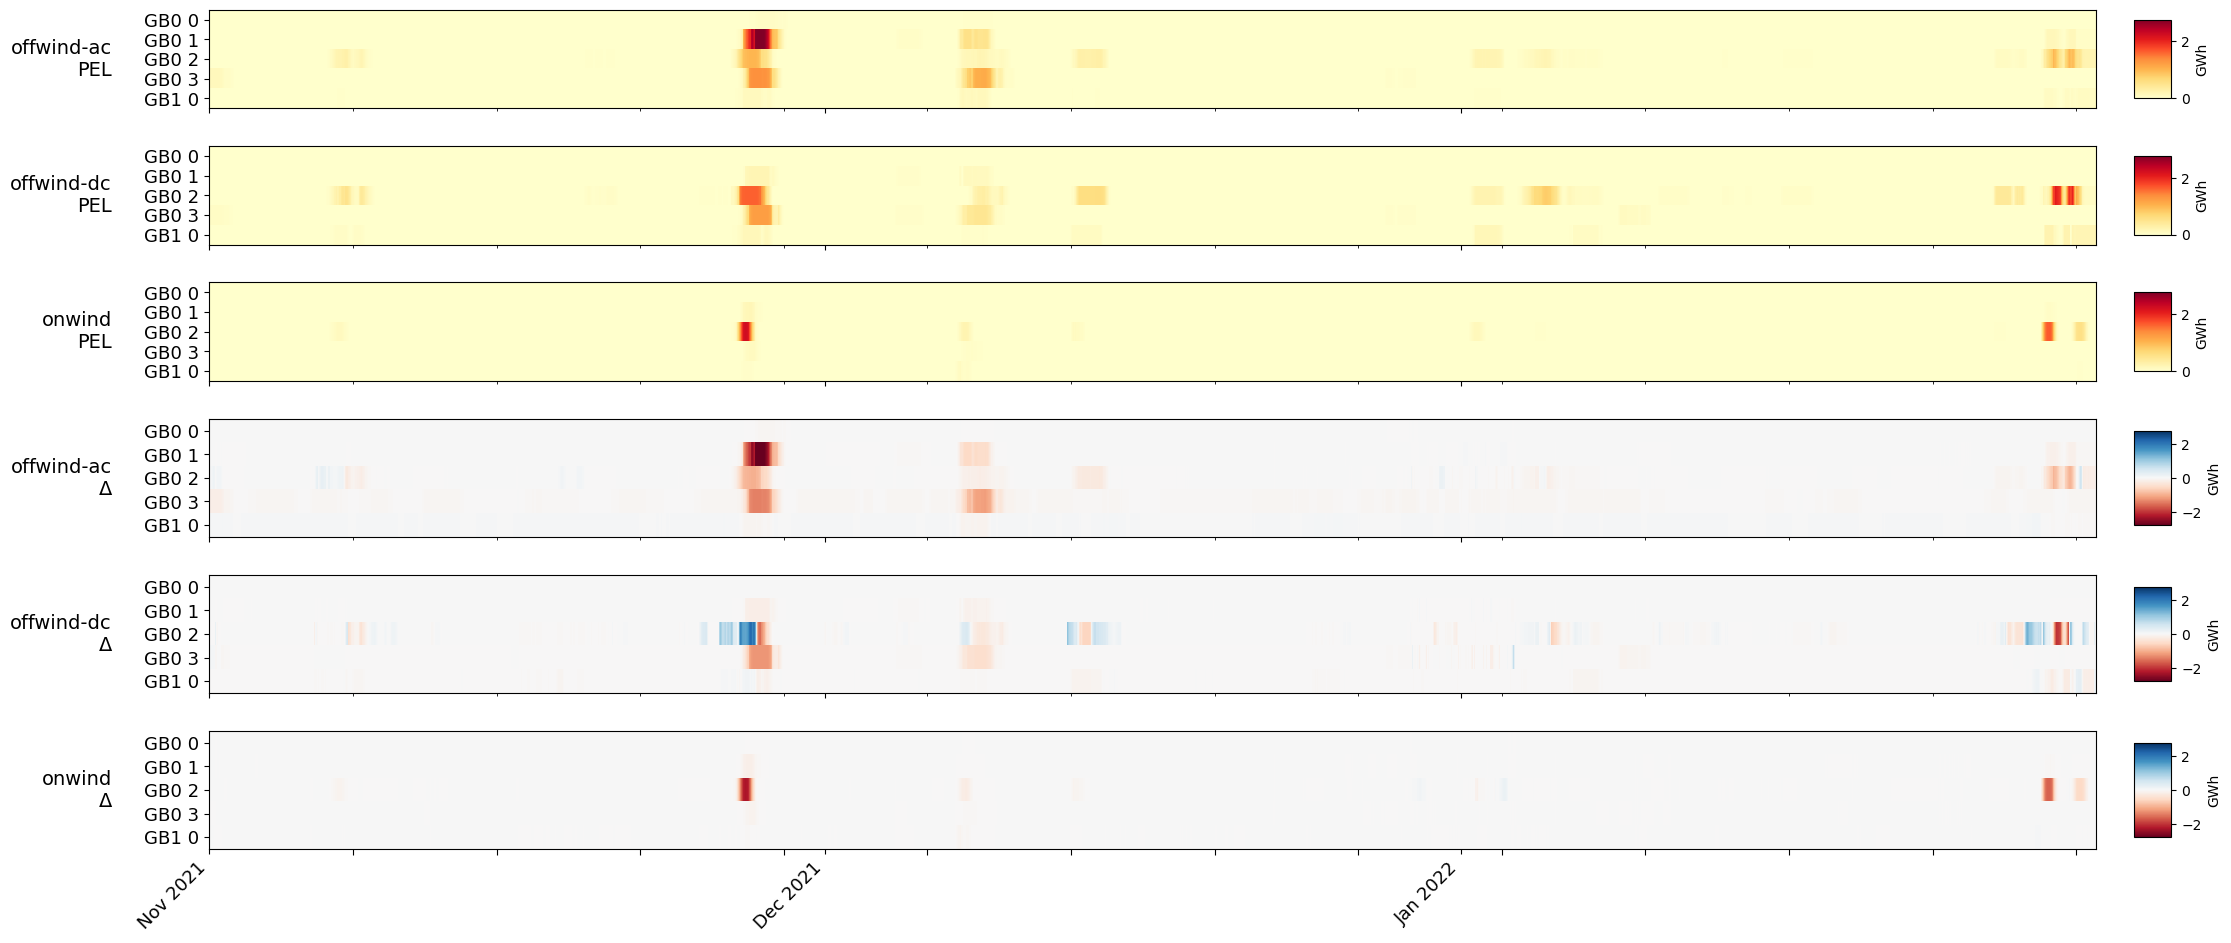

In [11]:
# Wind PEL vs EB diff — per bus, cap scenario
base = "base"
scen = "cap"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_cap)

fig, axes = plot_combination_profile(
    carrier_groups={c: c for c in WIND_CARRIERS},
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_win"],
            "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
        },
        "\u0394": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "wind", "row_height": 1.8,
        },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-11-01", f"{YEAR+1}-01-31"),
    title=None,
    fontsize=14,
    label_gap=70,
    fig_width=25,
)

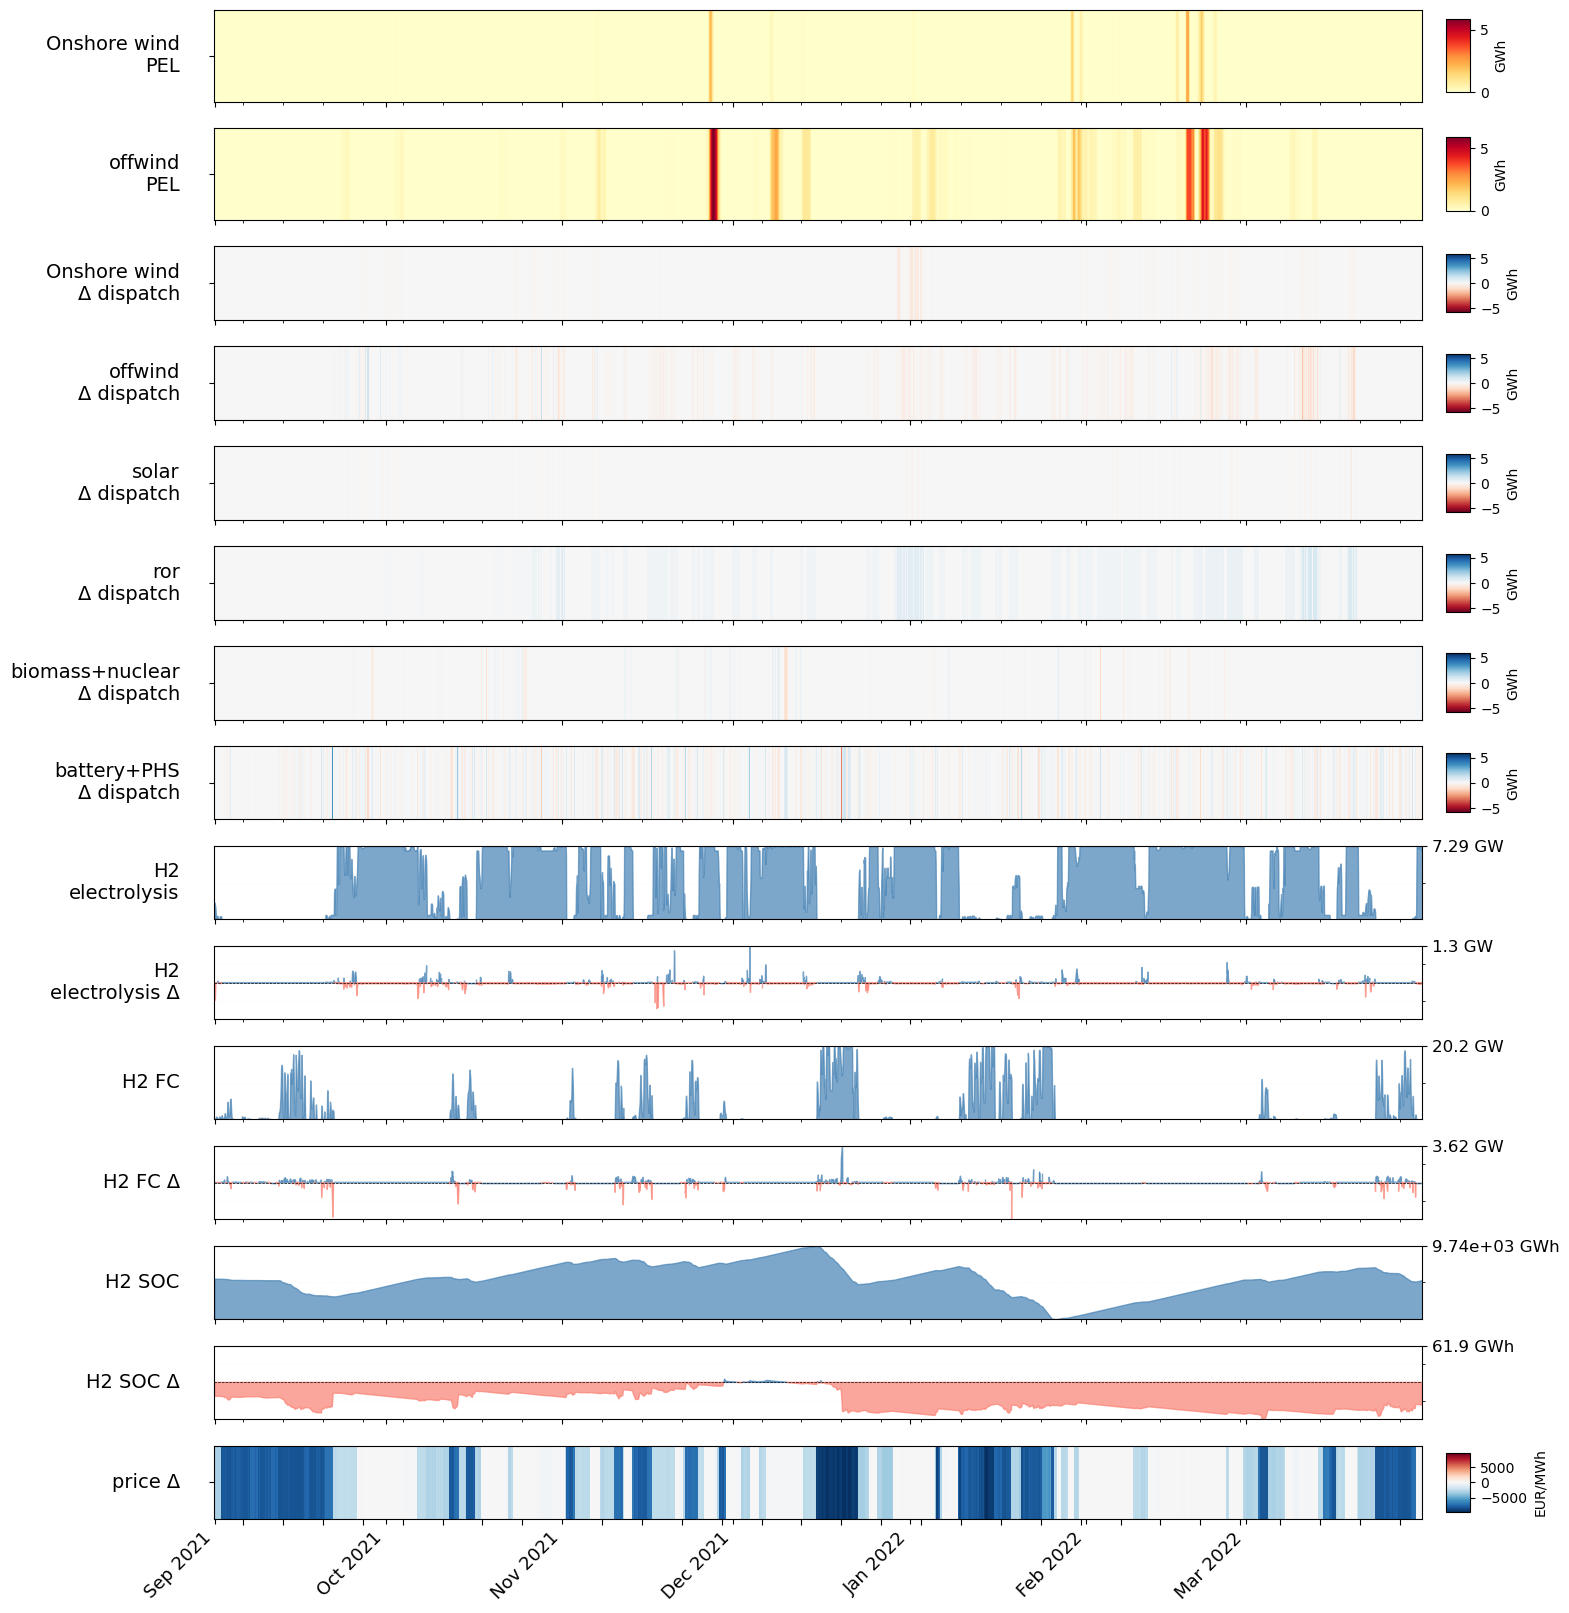

In [12]:
# Damaged dispatch — H2, SOC, price with diffs, winter
base = "dis"
scen = "cap"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_cap)

ls_diff = build_eb_diff_by_bus(d["ts_diff"], "load_shedding", scen) * 1e-3
bat_phs_diff = (
    build_eb_diff_by_bus(d["ts_diff"], "battery", scen)
    + build_eb_diff_by_bus(d["ts_diff"], "PHS", scen)
) * 1e-3

fig, axes = plot_combination_profile(
    carrier_groups={
        "Onshore wind":["onwind"],
        "offwind":offwind_group,
        "solar":solar_group,
        "ror":["ror"],
        "biomass+nuclear": ["biomass", "nuclear"],
        "battery+PHS": ["battery", "PHS"],
    },
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_win"],
            "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
        },
        "\u0394 dispatch": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "wind", 
            "row_height": 1.2,
        },
        # "battery+PHS \u0394": {
        #     "type": "direct", "data": bat_phs_diff,
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "unit": "GWh", "row_height": 1.2,
        # },
        # "load shedding": {
        #     "type": "direct", "data": d["ls_df"],
        #     "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        # },
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2\nelectrolysis \u0394": {
            "type": "direct", "data": d["elec_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC \u0394": {
            "type": "direct", "data": d["fc_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "price \u0394": {
            "type": "direct", "data": d["price_diff"],
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-09-01", f"{YEAR+1}-03-31"),
    title=None,
    fontsize=14,
    label_gap=25,
)



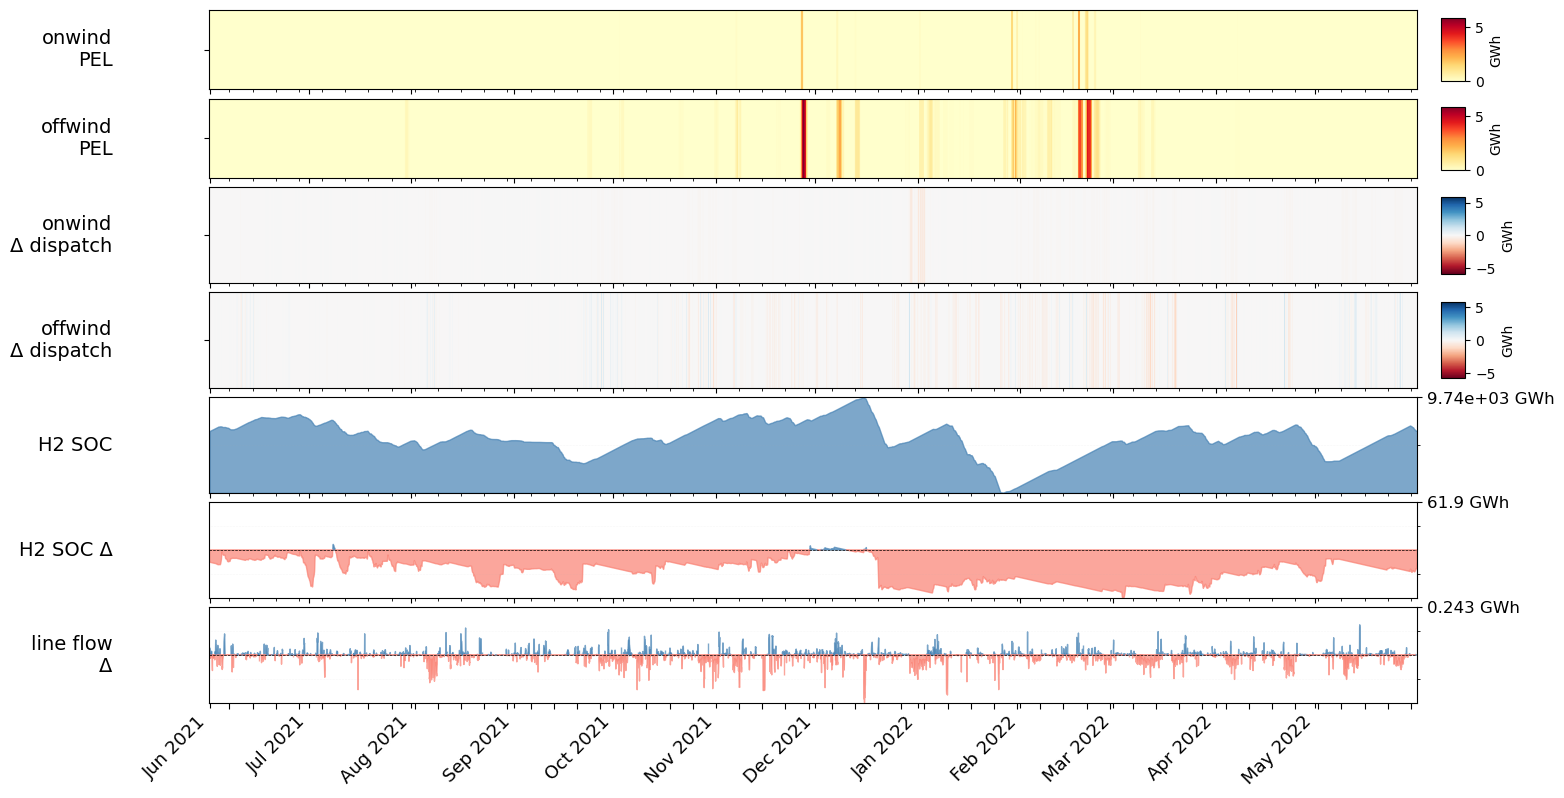

In [13]:
# Damaged dispatch — H2, SOC, price with diffs, winter
base = "dis"
scen = "cap"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_cap)

ls_diff = build_eb_diff_by_bus(d["ts_diff"], "load_shedding", scen) * 1e-3
bat_phs_diff = (
    build_eb_diff_by_bus(d["ts_diff"], "battery", scen)
    + build_eb_diff_by_bus(d["ts_diff"], "PHS", scen)
) * 1e-3

fig, axes = plot_combination_profile(
    carrier_groups={
        "onwind":["onwind"],
        "offwind":offwind_group,
        # "biomass+nuclear": ["biomass", "nuclear"],
        # "battery+PHS": ["battery", "PHS"],
    },
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_win"],
            "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "wind",
            "row_height": 1,

        },
        "\u0394 dispatch": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "wind", 
            "row_height": 1.2,
        },
        # "battery+PHS \u0394": {
        #     "type": "direct", "data": bat_phs_diff,
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "unit": "GWh", "row_height": 1.2,
        # },
        # "load shedding": {
        #     "type": "direct", "data": d["ls_df"],
        #     "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        # },
        # "H2\nelectrolysis": {
        #     "type": "direct", "data": d["elec_scen_df"],
        #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        # "H2\nelectrolysis \u0394": {
        #     "type": "direct", "data": d["elec_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        # "H2 FC": {
        #     "type": "direct", "data": d["fc_df"],
        #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        # "H2 FC \u0394": {
        #     "type": "direct", "data": d["fc_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "color": "steelblue", "neg_color": "salmon",
        #     "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        # },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        # "line flow\nscen": {
        #     "type": "direct", "data": d["flow_df"],
        #     "render": "area", "symmetric": True,
        #     "multiplier": 1e-3, "unit": "GWh",
        #     "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        # },
        "line flow\n\u0394": {
            "type": "direct", "data": d["flow_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        # "price \u0394": {
        #     "type": "direct", "data": d["price_diff"],
        #     "render": "heatmap", "cmap": "RdBu_r",
        #     "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        # },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-06-01", f"{YEAR+1}-05-31"),
    title=None,
    fontsize=14,
    label_gap=70,
    component_gap=0.1
)



# Aggregate Checks

In [51]:
from plot_combo import (
    plot_combination_profile,
    format_ts_df, format_ts_diff_df,
    build_eb_diff_by_bus, build_storage_dict,
)
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths_dis)


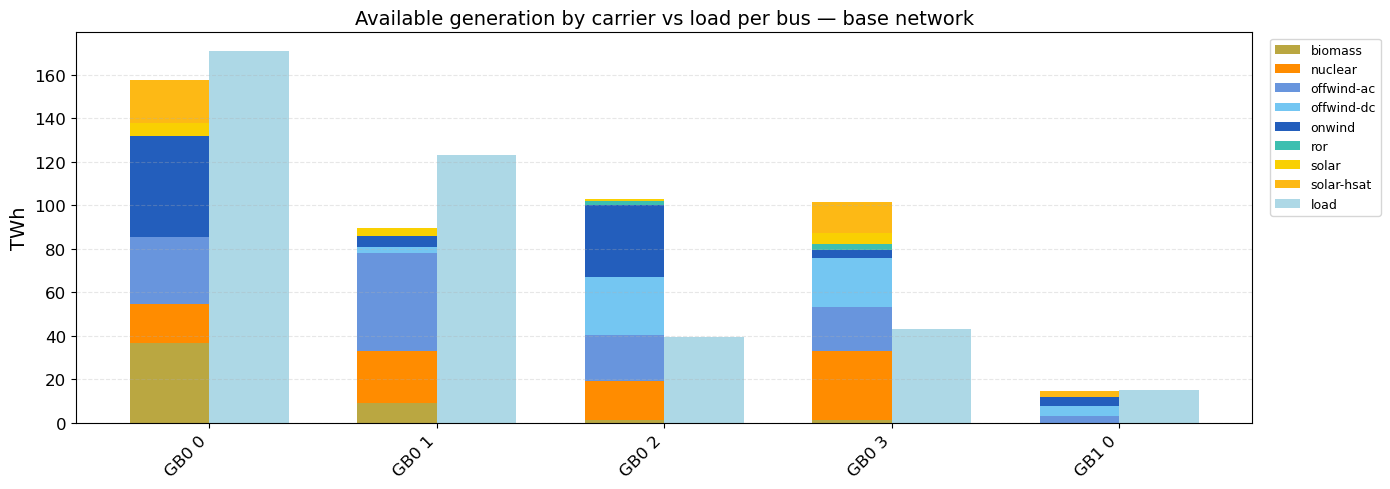

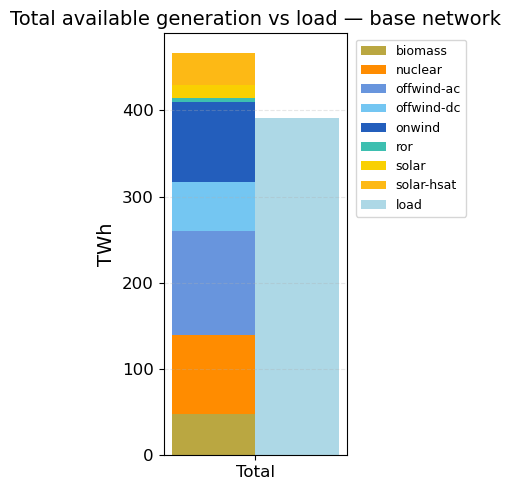

In [ ]:
n = networks["base"]

# ── Available generation per carrier per bus ───────────────────────────────────
gens = n.generators[~n.generators["carrier"].isin(["CCGT", "coal"])]

varying_idx = gens.index.intersection(n.generators_t.p_max_pu.columns)
static_idx  = gens.index.difference(varying_idx)

p_max_pu_sum = pd.Series(dtype=float)
if not varying_idx.empty:
    p_max_pu_sum = pd.concat([p_max_pu_sum, n.generators_t.p_max_pu[varying_idx].sum()])
if not static_idx.empty:
    p_max_pu_sum = pd.concat([p_max_pu_sum, gens.loc[static_idx, "p_max_pu"] * len(n.snapshots)])

avail_by_carrier_bus = (
    (gens["p_nom_opt"] * p_max_pu_sum)
    .rename("available_MWh")
    .to_frame()
    .assign(carrier=gens["carrier"], bus=gens["bus"])
    .groupby(["carrier", "bus"])["available_MWh"]
    .sum()
    .unstack("bus")
    .fillna(0)
) * 1e-6  # TWh

load_by_bus = (
    n.loads_t.p_set.sum()
    .rename("load_MWh")
    .to_frame()
    .assign(bus=n.loads["bus"])
    .groupby("bus")["load_MWh"]
    .sum()
) * 1e-6  # TWh

color_map = n.carriers.color.to_dict()
carriers  = avail_by_carrier_bus.index.tolist()

def _plot(ax, buses, title):
    x      = np.arange(len(buses))
    width  = 0.35
    bottom = np.zeros(len(buses))
    for carrier in carriers:
        vals  = avail_by_carrier_bus.loc[carrier, buses].values
        color = color_map.get(carrier, "#aaaaaa")
        ax.bar(x - width/2, vals, width, bottom=bottom, label=carrier, color=color)
        bottom += vals
    ax.bar(x + width/2, load_by_bus.reindex(buses).values, width, label="load", color="lightblue")
    ax.set_xticks(x)
    ax.set_xticklabels(buses, rotation=45, ha="right")
    ax.set_ylabel("TWh")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")

per_bus_cols = avail_by_carrier_bus.columns.tolist()

# ── Plot 1: per bus ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 5))
_plot(ax1, per_bus_cols, f"Available generation by carrier vs load per bus — {base} network")
ax1.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# ── Plot 2: total ──────────────────────────────────────────────────────────────
avail_total = avail_by_carrier_bus.sum(axis=1).to_frame("Total")
load_total  = pd.Series({"Total": load_by_bus.sum()})

fig2, ax2 = plt.subplots(figsize=(4, 5))
bottom = 0.0
for carrier in carriers:
    val   = float(avail_total.loc[carrier, "Total"])
    color = color_map.get(carrier, "#aaaaaa")
    ax2.bar(0 - 0.175, val, 0.35, bottom=bottom, label=carrier, color=color)
    bottom += val
ax2.bar(0 + 0.175, float(load_total["Total"]), 0.35, label="load", color="lightblue")
ax2.set_xticks([0])
ax2.set_xticklabels(["Total"])
ax2.set_ylabel("TWh")
ax2.set_title(f"Total available generation vs load — {base} network")
ax2.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax2.grid(True, axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


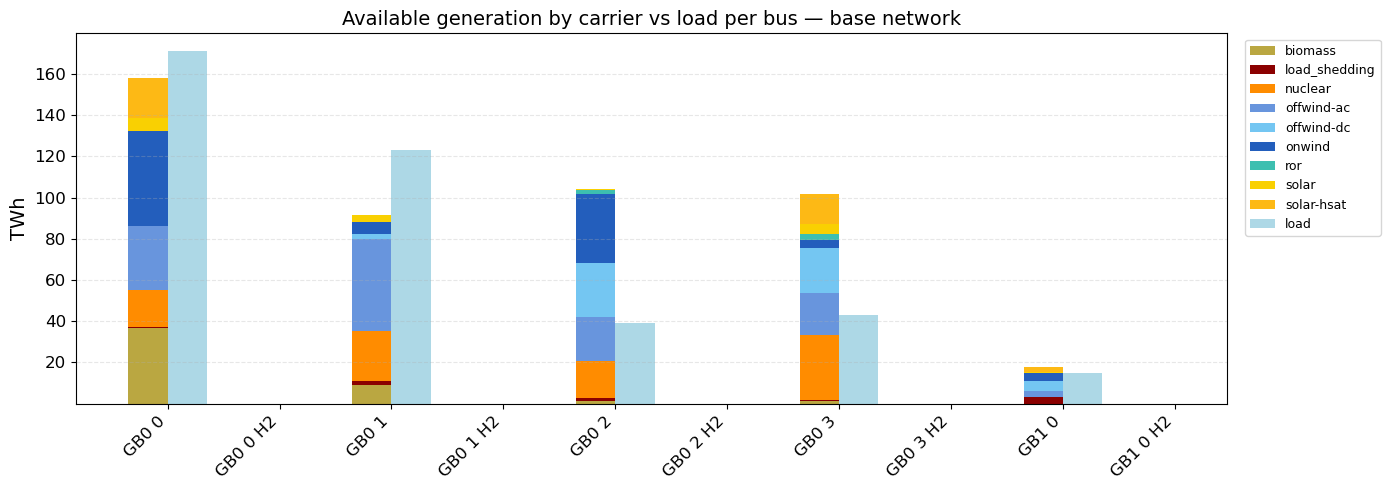

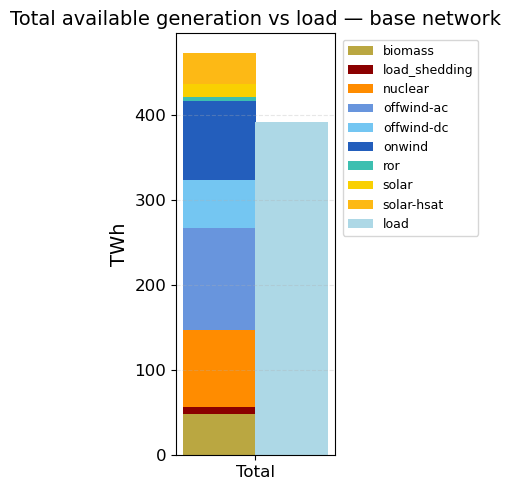

In [ ]:
n = networks["dis"]

# ── Available generation per carrier per bus ───────────────────────────────────
gens = n.generators[~n.generators["carrier"].isin(["CCGT", "coal"])]

varying_idx = gens.index.intersection(n.generators_t.p_max_pu.columns)
static_idx  = gens.index.difference(varying_idx)

p_max_pu_sum = pd.Series(dtype=float)
if not varying_idx.empty:
    p_max_pu_sum = pd.concat([p_max_pu_sum, n.generators_t.p_max_pu[varying_idx].sum()])
if not static_idx.empty:
    p_max_pu_sum = pd.concat([p_max_pu_sum, gens.loc[static_idx, "p_max_pu"] * len(n.snapshots)])

avail_by_carrier_bus = (
    (gens["p_nom_opt"] * p_max_pu_sum)
    .rename("available_MWh")
    .to_frame()
    .assign(carrier=gens["carrier"], bus=gens["bus"])
    .groupby(["carrier", "bus"])["available_MWh"]
    .sum()
    .unstack("bus")
    .fillna(0)
) * 1e-6  # TWh

load_by_bus = (
    n.loads_t.p_set.sum()
    .rename("load_MWh")
    .to_frame()
    .assign(bus=n.loads["bus"])
    .groupby("bus")["load_MWh"]
    .sum()
) * 1e-6  # TWh

color_map = n.carriers.color.to_dict()
carriers  = avail_by_carrier_bus.index.tolist()

def _plot(ax, buses, title):
    x      = np.arange(len(buses))
    width  = 0.35
    bottom = np.zeros(len(buses))
    for carrier in carriers:
        vals  = avail_by_carrier_bus.loc[carrier, buses].values
        color = color_map.get(carrier, "#aaaaaa")
        ax.bar(x - width/2, vals, width, bottom=bottom, label=carrier, color=color)
        bottom += vals
    ax.bar(x + width/2, load_by_bus.reindex(buses).values, width, label="load", color="lightblue")
    ax.set_xticks(x)
    ax.set_xticklabels(buses, rotation=45, ha="right")
    ax.set_ylabel("TWh")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")

per_bus_cols = avail_by_carrier_bus.columns.tolist()

# ── Plot 1: per bus ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 5))
_plot(ax1, per_bus_cols, f"Available generation by carrier vs load per bus — {base} network")
ax1.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# ── Plot 2: total ──────────────────────────────────────────────────────────────
avail_total = avail_by_carrier_bus.sum(axis=1).to_frame("Total")
load_total  = pd.Series({"Total": load_by_bus.sum()})

fig2, ax2 = plt.subplots(figsize=(4, 5))
bottom = 0.0
for carrier in carriers:
    val   = float(avail_total.loc[carrier, "Total"])
    color = color_map.get(carrier, "#aaaaaa")
    ax2.bar(0 - 0.175, val, 0.35, bottom=bottom, label=carrier, color=color)
    bottom += val
ax2.bar(0 + 0.175, float(load_total["Total"]), 0.35, label="load", color="lightblue")
ax2.set_xticks([0])
ax2.set_xticklabels(["Total"])
ax2.set_ylabel("TWh")
ax2.set_title(f"Total available generation vs load — {base} network")
ax2.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax2.grid(True, axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


## Check PEL vs change in nuclear

In [79]:
from plot_stats import compute_stats_diff, format_stats_df
grouper = ["bus", "carrier", "bus_carrier"]
stats = nc.statistics(groupby=grouper, nice_names=False)
diff = compute_stats_diff(stats, base="base")
diff = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])


## Total year

### PEL VS SUPPLY DIFF TOTAL

In [52]:
pel_by_bus = (
    pd.concat([df.sum(axis=0) for df in d["pel_dict_win"].values()], axis=1)
    .sum(axis=1)
    .rename("PEL (GWh)")
)

wind_mask = (
    (d["ts_diff"]["carrier"].isin(WIND_CARRIERS)) &
    (d["ts_diff"]["bus_carrier"] == "AC")
)

eb_diff_by_bus = (
    d["ts_diff"][wind_mask & (d["ts_diff"]["network"] == scen)]
    .groupby("bus")["value_diff"]
    .sum()
    .rename("EB diff (GWh)")
)

base_eb_by_bus = (
    d["ts_diff"][wind_mask & (d["ts_diff"]["network"] == base)]
    .groupby("bus")["value"]
    .sum()
    .rename("base EB (GWh)")
)

per_bus = pd.concat([pel_by_bus, eb_diff_by_bus, base_eb_by_bus], axis=1) / 1e3
per_bus["EB diff / PEL (%)"]     = (per_bus["EB diff (GWh)"].abs() / per_bus["PEL (GWh)"]) * 100
per_bus["EB diff / base EB (%)"] = (per_bus["EB diff (GWh)"].abs() / per_bus["base EB (GWh)"].abs()) * 100

total = per_bus.sum(numeric_only=True).to_frame("Total").T
total["EB diff / PEL (%)"]     = (total["EB diff (GWh)"].abs() / total["PEL (GWh)"]) * 100
total["EB diff / base EB (%)"] = (total["EB diff (GWh)"].abs() / total["base EB (GWh)"].abs()) * 100

total


,PEL (GWh),EB diff (GWh),base EB (GWh),EB diff / PEL (%),EB diff / base EB (%)
Total,1333.426573,-339.745838,259245.494562,25.479156,0.131052


In [53]:
print(per_bus)

        PEL (GWh)  EB diff (GWh)  base EB (GWh)  EB diff / PEL (%)  \
bus                                                                  
GB0 0  127.176364     -94.418347   77022.920942          74.242056   
GB0 1  241.623216    -159.712372   52926.341368          66.099763   
GB0 2  537.975145     328.235583   72536.175374          61.013150   
GB0 3  334.526287    -260.826254   45972.553551          77.968836   
GB1 0   92.125561    -153.024448   10787.503327         166.104225   

       EB diff / base EB (%)  
bus                           
GB0 0               0.122585  
GB0 1               0.301763  
GB0 2               0.452513  
GB0 3               0.567352  
GB1 0               1.418534  


In [54]:
print(total)

         PEL (GWh)  EB diff (GWh)  base EB (GWh)  EB diff / PEL (%)  \
Total  1333.426573    -339.745838  259245.494562          25.479156   

       EB diff / base EB (%)  
Total               0.131052  


In [ ]:
scen

'dis'

### PEL VS SUPPLY DIFF per wind

In [89]:
rows = []
for carrier in WIND_CARRIERS:
    mask = (
        (d["ts_diff"]["carrier"] == carrier) &
        (d["ts_diff"]["bus_carrier"] == "AC")
    )

    pel = d["pel_dict_win"][carrier].sum(axis=0).sum() / 1e3

    eb_diff = (
        d["ts_diff"][mask & (d["ts_diff"]["network"] == scen)]
        ["value_diff"].sum() / 1e3
    )
    base_eb = (
        d["ts_diff"][mask & (d["ts_diff"]["network"] == base)]
        ["value"].sum() / 1e3
    )

    rows.append({
        "carrier":             carrier,
        "PEL (GWh)":           pel,
        "EB diff (GWh)":       eb_diff,
        "base EB (GWh)":       base_eb,
        "EB diff / PEL (%)":   abs(eb_diff) / pel * 100,
        "EB diff / base EB (%)": abs(eb_diff) / abs(base_eb) * 100,
    })

per_carrier = pd.DataFrame(rows).set_index("carrier")

total = per_carrier.sum(numeric_only=True).to_frame("Total").T
total["EB diff / PEL (%)"]       = total["EB diff (GWh)"].abs() / total["PEL (GWh)"] * 100
total["EB diff / base EB (%)"]   = total["EB diff (GWh)"].abs() / total["base EB (GWh)"].abs() * 100

pd.concat([per_carrier, total])


KeyError: 'offwind-ac'

In [79]:
from plot_stats import compute_stats_diff, format_stats_df

grouper = ["bus", "carrier", "bus_carrier"]
stats = nc.statistics(groupby=grouper, nice_names=False)
diff = compute_stats_diff(stats, base="base")
diff = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])


In [85]:
carriers = diff["tech"].dropna().unique()

rows = []
for carrier in carriers:
    mask = (
        (diff["tech"] == carrier) &
        (diff["bus_carrier"] == "AC") 
        # (diff["bus_carrier"] == "H2")
    )

    eb_diff = (
        diff[mask & (diff["network"] == scen)]
        ["energy_balance_diff"].sum() * 1e-3
    )
    base_eb = (
        diff[mask & (diff["network"] == base)]
        ["energy balance"].sum() * 1e-3
    )

    rows.append({
        "carrier":               carrier,
        "EB diff (GWh)":         eb_diff,
        "base EB (GWh)":         base_eb,
        "EB diff / base EB (%)": abs(eb_diff) / abs(base_eb) * 100 if base_eb else None,
    })

per_carrier = pd.DataFrame(rows).set_index("carrier").sort_values("EB diff (GWh)")

total = per_carrier.sum(numeric_only=True).to_frame("Total").T
total["EB diff / base EB (%)"] = total["EB diff (GWh)"].abs() / total["base EB (GWh)"].abs() * 100

pd.concat([per_carrier, total])



,EB diff (GWh),base EB (GWh),EB diff / base EB (%)
ror,-586.629674,3883.926320,15.104037
offwind-dc,-357.132643,47731.906345,0.748205
AC,-32.714970,96202.850520,0.034006
offwind-ac,-16.796964,119036.644447,0.014111
H2 fuel cell,0.000000,0.000000,NaN
coal,0.000000,0.000000,NaN
CCGT,0.000000,0.000000,NaN
load,0.000000,-391812.258953,0.000000
H2,0.000000,0.000000,NaN
hydro,0.011169,254.827666,0.004383


In [87]:
rows = []
for carrier in carriers:
    mask = (
        (diff["tech"] == carrier) &
        # (diff["bus_carrier"] == "AC") 
        (diff["bus_carrier"] == "H2")
    )

    eb_diff = (
        diff[mask & (diff["network"] == scen)]
        ["energy_balance_diff"].sum() * 1e-3
    )
    base_eb = (
        diff[mask & (diff["network"] == base)]
        ["energy balance"].sum() * 1e-3
    )

    rows.append({
        "carrier":               carrier,
        "EB diff (GWh)":         eb_diff,
        "base EB (GWh)":         base_eb,
        "EB diff / base EB (%)": abs(eb_diff) / abs(base_eb) * 100 if base_eb else None,
    })

per_carrier = pd.DataFrame(rows).set_index("carrier").sort_values("EB diff (GWh)")

total = per_carrier.sum(numeric_only=True).to_frame("Total").T
total["EB diff / base EB (%)"] = total["EB diff (GWh)"].abs() / total["base EB (GWh)"].abs() * 100

pd.concat([per_carrier, total])

,EB diff (GWh),base EB (GWh),EB diff / base EB (%)
H2,-0.000006,0.013806,0.040418
CCGT,0.000000,0.000000,NaN
nuclear,0.000000,0.000000,NaN
biomass,0.000000,0.000000,NaN
offwind-dc,0.000000,0.000000,NaN
onwind,0.000000,0.000000,NaN
solar,0.000000,0.000000,NaN
offwind-ac,0.000000,0.000000,NaN
coal,0.000000,0.000000,NaN
ror,0.000000,0.000000,NaN


In [78]:
64.069952*0.699

44.784896448

In [88]:
44.784896448 * 0.5

22.392448224

In [76]:
per_bus

,PEL (GWh),offwind-ac,offwind-dc,onwind,wind EB diff (GWh),wind EB diff / PEL (%)
bus,,,,,,
GB0 0,127.178003,-79.119698,-0.582851,-42.547213,-122.249762,96.124926
GB0 1,241.623209,-209.573920,-17.904302,-6.530611,-234.008833,96.848657
GB0 2,537.955863,24.258681,-14.225657,-78.398273,-68.365249,12.708338
GB0 3,334.556701,-154.265076,-168.716824,-6.817240,-329.799141,98.577951
GB1 0,92.118429,-20.895138,-9.220286,0.520104,-29.595319,32.127469


In [77]:
total

,PEL (GWh),offwind-ac,offwind-dc,onwind,wind EB diff (GWh),wind EB diff / PEL (%)
Total,1333.432205,-439.59515,-210.64992,-133.773234,-784.018304,336.387341


In [ ]:
eta_elec  = n.links.loc[n.links["carrier"] == "H2 electrolysis", "efficiency"].iloc[0]
eta_fc    = n.links.loc[n.links["carrier"] == "H2 fuel cell",    "efficiency"].iloc[0]

In [ ]:
for name, n in networks.items():
    h2 = n.stores.index[n.stores.carrier == "H2"]
    soc = n.stores_t.e[h2]
    print(f"{name}  start: {soc.iloc[0].sum():.1f} MWh  end: {soc.iloc[-1].sum():.1f} MWh")


base  start: 6309653.3 MWh  end: 6302322.0 MWh
base_dis  start: 6327488.2 MWh  end: 6320157.2 MWh
cap  start: 6293807.0 MWh  end: 6286516.0 MWh
cap_on  start: 6301732.0 MWh  end: 6294441.0 MWh
dis  start: 6309653.3 MWh  end: 6302322.0 MWh


In [63]:
for name, n in networks.items():
    print(f"\n── {name} ──")

    # H2 stores
    h2_idx = n.stores.index[n.stores.carrier == "H2"]
    if len(h2_idx):
        soc = n.stores_t.e[h2_idx]
        print(f"  H2      start: {soc.iloc[0].sum():.1f} MWh  end: {soc.iloc[-1].sum():.1f} MWh  max: {soc.sum(axis=1).max():.1f} MWh  min: {soc.sum(axis=1).min():.1f} MWh")

    # StorageUnits (battery, PHS, hydro)
    for carrier in ["battery", "PHS", "hydro"]:
        idx = n.storage_units.index[n.storage_units.carrier == carrier]
        if len(idx):
            soc = n.storage_units_t.state_of_charge[idx]
            print(f"  {carrier:<8} start: {soc.iloc[0].sum():.1f} MWh  end: {soc.iloc[-1].sum():.1f} MWh  max: {soc.sum(axis=1).max():.1f} MWh  min: {soc.sum(axis=1).min():.1f} MWh")



── base ──
  H2      start: 6309653.3 MWh  end: 6302322.0 MWh  max: 9746788.5 MWh  min: 2947.9 MWh
  battery  start: 8495.2 MWh  end: 0.0 MWh  max: 228722.9 MWh  min: 0.0 MWh
  PHS      start: 283.4 MWh  end: 0.0 MWh  max: 7000.0 MWh  min: 0.0 MWh
  hydro    start: 146197.4 MWh  end: 146172.5 MWh  max: 159449.5 MWh  min: 37356.8 MWh

── base_dis ──
  H2      start: 6327488.2 MWh  end: 6320157.2 MWh  max: 9746647.7 MWh  min: 2953.6 MWh
  battery  start: 8425.2 MWh  end: 0.0 MWh  max: 228722.2 MWh  min: 0.0 MWh
  PHS      start: 307.7 MWh  end: 0.0 MWh  max: 7000.0 MWh  min: 0.0 MWh
  hydro    start: 139485.9 MWh  end: 139461.0 MWh  max: 159059.4 MWh  min: 40391.6 MWh

── cap ──
  H2      start: 6293807.0 MWh  end: 6286516.0 MWh  max: 9743414.5 MWh  min: 3130.7 MWh
  battery  start: 8543.5 MWh  end: 0.0 MWh  max: 233427.2 MWh  min: 0.0 MWh
  PHS      start: 283.5 MWh  end: 0.0 MWh  max: 7000.0 MWh  min: 0.0 MWh
  hydro    start: 146903.4 MWh  end: 146878.5 MWh  max: 161907.0 MWh  min: 3

In [56]:


soc_utilisation = pd.DataFrame({
    "e_nom_opt (MWh)":    d["h2_e_nom_by_bus"],
    "max SOC base (MWh)": d["soc_base"].max(),
    "max SOC base at":    d["soc_base"].idxmax(),
    "max SOC scen (MWh)": d["soc_scen"].max(),
    "max SOC scen at":    d["soc_scen"].idxmax(),
    "min SOC base (MWh)": d["soc_base"].min(),
    "min SOC base at":    d["soc_base"].idxmin(),
    "min SOC scen (MWh)": d["soc_scen"].min(),
    "min SOC scen at":    d["soc_scen"].idxmin(),
})
soc_utilisation["utilisation base (%)"] = (
    soc_utilisation["max SOC base (MWh)"] / soc_utilisation["e_nom_opt (MWh)"] * 100
).round(1)
soc_utilisation["utilisation scen (%)"] = (
    soc_utilisation["max SOC scen (MWh)"] / soc_utilisation["e_nom_opt (MWh)"] * 100
).round(1)
soc_utilisation["max SOC diff (MWh)"] = (
    soc_utilisation["max SOC scen (MWh)"] - soc_utilisation["max SOC base (MWh)"]
).round(1)

soc_utilisation
soc_utilisation.to_csv(root.parent.parent.parent / "results" / f"h2_soc_utilisation_GB-{YEAR}.csv")


In [57]:
soc_utilisation

,e_nom_opt (MWh),max SOC base (MWh),max SOC base at,max SOC scen (MWh),max SOC scen at,min SOC base (MWh),min SOC base at,min SOC scen (MWh),min SOC scen at,utilisation base (%),utilisation scen (%),max SOC diff (MWh)
bus,,,,,,,,,,,,
GB0 0 H2,6.229303e+06,6.229303e+06,2021-12-15 14:00:00,6.229303e+06,2021-12-15 14:00:00,0.001058,2022-01-26 10:00:00,0.000253,2022-01-26 10:00:00,100.0,100.0,0.0
GB0 1 H2,2.828579e+06,2.828579e+06,2021-12-15 14:00:00,2.828579e+06,2021-12-15 14:00:00,0.001074,2022-01-26 10:00:00,0.000140,2022-01-26 10:00:00,100.0,100.0,0.0
GB0 2 H2,6.860098e+01,6.859867e+01,2021-12-15 15:00:00,6.860099e+01,2022-03-15 20:00:00,0.005915,2021-09-20 10:00:00,0.000040,2021-09-20 10:00:00,100.0,100.0,0.0
GB0 3 H2,2.469212e+05,2.469212e+05,2021-12-15 14:00:00,2.469212e+05,2021-12-15 14:00:00,0.001016,2022-01-26 10:00:00,0.000090,2022-01-26 10:00:00,100.0,100.0,0.0
GB1 0 H2,4.419162e+05,4.419162e+05,2021-12-15 14:00:00,4.419162e+05,2021-12-15 14:00:00,0.003083,2022-01-25 21:00:00,0.000187,2021-09-20 10:00:00,100.0,100.0,0.0


## Aggregate line flows

In [49]:
def _flow_by_bus(network, col="value"):
    mask = (
        (d["ts_diff"]["carrier"].isin(["AC", "DC"])) &
        (d["ts_diff"]["network"] == network) &
        (d["ts_diff"]["bus_carrier"] == "AC")
    )
    return d["ts_diff"][mask].groupby("bus")[col].sum() / 1e3

line_base = _flow_by_bus(base, "value").rename("net flow base (GWh)")
line_scen = _flow_by_bus(scen, "value").rename("net flow scen (GWh)")
line_diff = _flow_by_bus(scen, "value_diff").rename("net flow diff (GWh)")

line_flows = pd.concat([line_base, line_scen, line_diff], axis=1)
line_flows.loc["Total"] = line_flows.sum()

line_flows



,net flow base (GWh),net flow scen (GWh),net flow diff (GWh)
bus,,,
GB0 0,42312.986616,42283.710865,-29.275752
GB0 1,51733.555337,51516.636793,-216.918544
GB0 2,-49381.999518,-49310.307056,71.692462
GB0 3,-51657.002237,-51480.825643,176.176594
GB1 0,3322.788748,3404.676355,81.887608
Total,-3669.671053,-3586.108685,83.562368


# Prices

Text(0.5, 0, '')

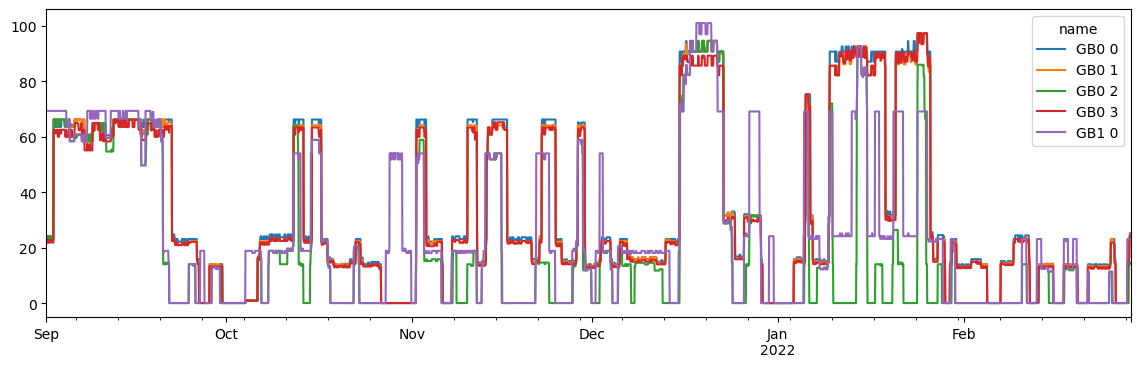

In [93]:
n = networks["base_dis"]
ac_buses = n.buses.index[n.buses.carrier == "AC"].tolist()

date_range = (f"{YEAR}-09-01", f"{YEAR+1}-02-28")
figsize = (14, 4)

prices = n.buses_t.marginal_price[ac_buses]
if date_range is not None:
    prices = prices.loc[date_range[0]:date_range[1]]

ax = prices.plot(figsize=figsize)
ax.set_xlabel("")



Text(0.5, 0, '')

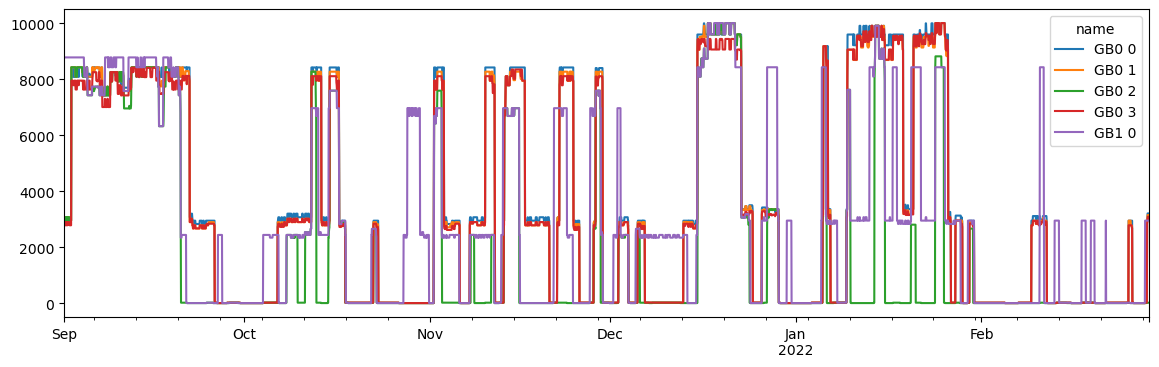

In [102]:
n = networks["dis"]
ac_buses = n.buses.index[n.buses.carrier == "AC"].tolist()

date_range = (f"{YEAR}-09-01", f"{YEAR+1}-02-28")
figsize = (14, 4)

prices = n.buses_t.marginal_price[ac_buses]
if date_range is not None:
    prices = prices.loc[date_range[0]:date_range[1]]

ax = prices.plot(figsize=figsize)
ax.set_xlabel("")



In [94]:
28.85/339.75

0.08491537895511406

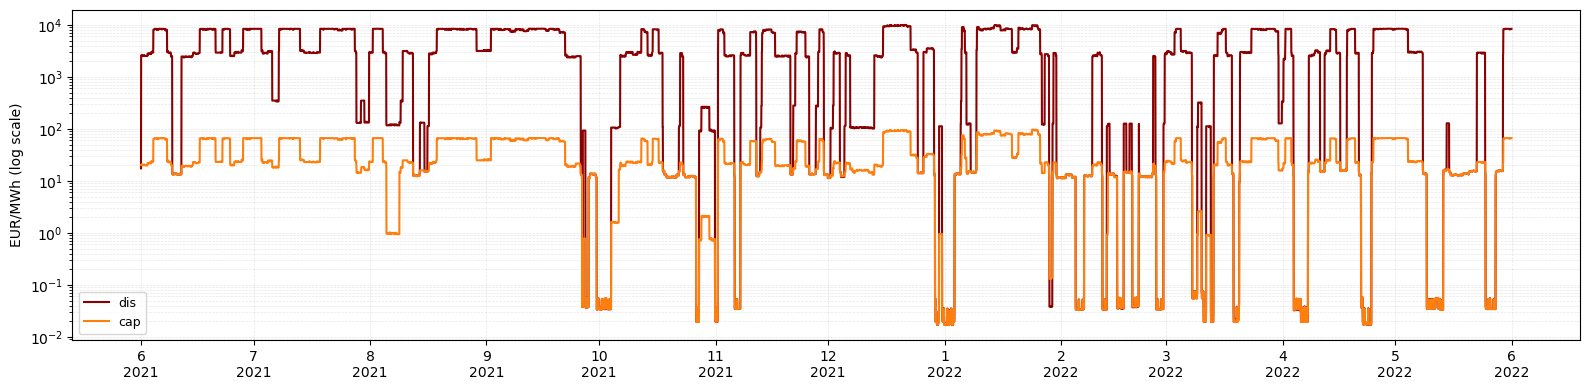

In [61]:
plot_networks = {
    "dis": nc.networks["dis"],
    "cap": nc.networks["cap_op"],
}
colors = {
    "dis": "darkred",
    "cap": "#ff7f0e",
}

fig, ax = plt.subplots(figsize=(16, 4))
for label, n in plot_networks.items():
    price = _fleet_price(n)
    ax.semilogy(price.index, price.values, linewidth=1.5, label=label, color=colors[label])
ax.set_ylabel("EUR/MWh (log scale)")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3, linestyle="--", linewidth=0.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%-m\n%Y"))
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()


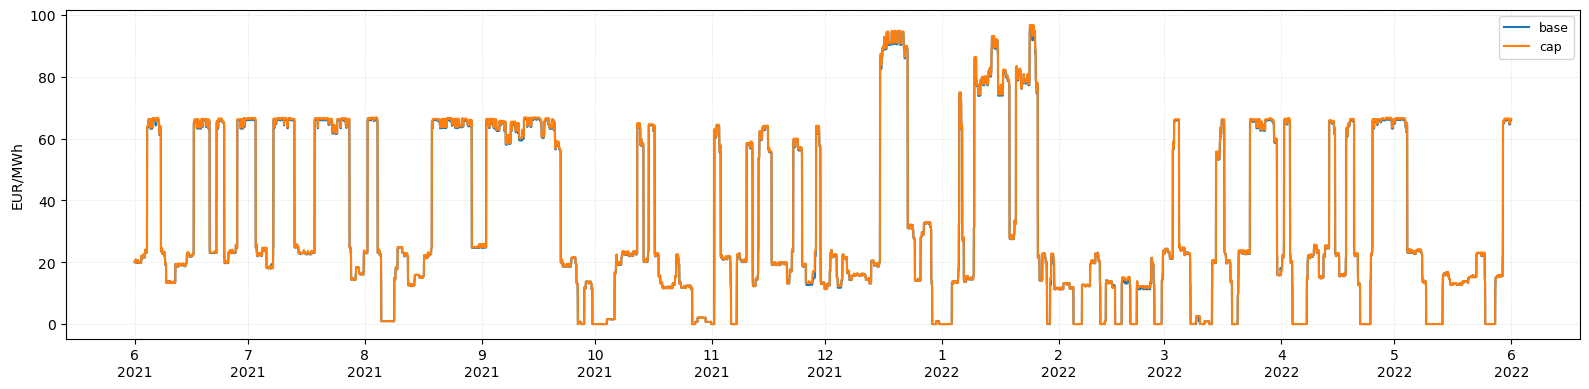

In [62]:
plot_networks = {
    # "base": nc.networks["base_dis"],
    "base": nc.networks["base_dis"],
    "cap": nc.networks["cap_op"],
}

fig, ax = plt.subplots(figsize=(16, 4))
for label, n in plot_networks.items():
    price = _fleet_price(n)
    ax.plot(price.index, price.values, linewidth=1.5, label=label)
ax.set_ylabel("EUR/MWh")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3, linestyle="--", linewidth=0.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%-m\n%Y"))
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()


In [63]:
def _load_weighted_avg_price(n):
    ac_buses  = n.buses.index[n.buses.carrier == "AC"]
    prices    = n.buses_t.marginal_price[ac_buses]

    # aggregate all loads by bus
    load_idx  = n.loads[n.loads.bus.isin(ac_buses)].index
    load_p    = n.loads_t.p_set[load_idx]
    load_by_bus = load_p.T.groupby(n.loads.loc[load_idx, "bus"]).sum().T
    load_by_bus = load_by_bus.reindex(columns=ac_buses, fill_value=0)

    total_cost = (prices * load_by_bus).values.sum()
    total_load = load_by_bus.values.sum()
    return total_cost / total_load   # EUR/MWh

print(f"dis:    {_load_weighted_avg_price(nc.networks['dis']):.2f} EUR/MWh")
print(f"cap_op: {_load_weighted_avg_price(nc.networks['cap_op']):.2f} EUR/MWh")
print(f"base: {_load_weighted_avg_price(nc.networks['base_dis']):.2f} EUR/MWh")



dis:    3706.53 EUR/MWh
cap_op: 33.60 EUR/MWh
base: 33.40 EUR/MWh
